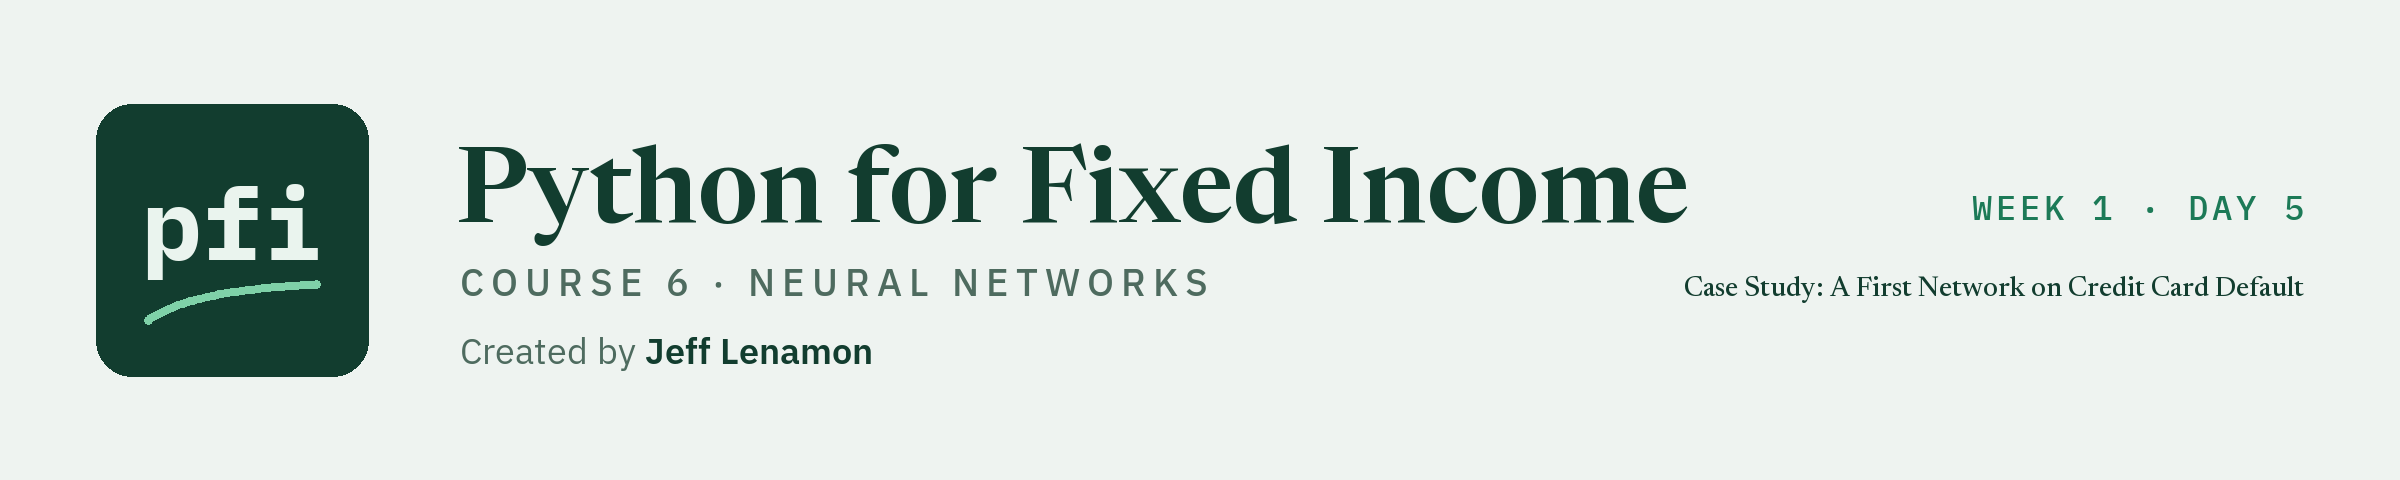

# Case Study: A First Network on Credit Card Default

Week 1, Day 5. Week 1 ends with a case study: a first network on the card file, chosen one setting at a time on rows carved from the training rows, put beside Course 4's logistic regression and Course 5's LightGBM on the same validation rows with bootstrap intervals, and a written description of what it shows and where it fails.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course6_neural_networks/week1/day5/05_case_study_a_first_network_on_credit_card_default.ipynb)

Days 1 to 4 built a network from the inside: one neuron fitted by hand, the same neuron in Keras, hidden layers, and the epochs, batches, and loss curves of a run of `fit`. Today the pieces become a model you can put beside the ones you already have. The question a colleague asks is plain: **on this card file, does a small dense network rank the accounts better than Course 4's logistic regression and Course 5's LightGBM, and how sure can anyone be?**

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16 and Courses 4 and 5 modelled. The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are in no model, and no output is grouped by them. Every model today uses the other 19 columns.
* **Course 4's split, rebuilt, with its test rows closed.** A case study is where a test set is usually opened, so day 1's rule is quoted here in full:

**The test-row rule.** A row that an earlier course used as a test row is never scored in Course 6. On the card file that means Course 4's 6,000 test rows. Course 4 opened them once, on day 10, and reported on them; scoring them again for a new round of models, after their numbers have been seen, would turn them into rows the course chooses against. `ensemblekit.course4_card_rows`, Course 5's function, rebuilds Course 4's split with the same two cuts and the same seed and returns only the training and validation rows, so a closed row cannot be scored by accident. The validation rows were used in Course 4 to choose and in Course 5 to report; Course 6 chooses nothing on them. From day 2 every setting is chosen on rows carved from the training rows (a stratified fifth, 3,600 rows, to stop or choose on) or by folds inside them, and the validation rows report once per chosen model, labelled validation, never test.

* **A model's output is described, never acted on.** A network's output is the model probability of default in this file, or a flag at a threshold; a network fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

The day has two halves.

**Hands-on, sections 5.1 to 5.3.**

1. `dense_classifier`: the course's default network, built inside a function that seeds it, so two builds start from the same weights.
2. `cv_network`: five folds inside the training rows, with stopping rows carved from each fold, giving one out-of-fold output per training row; and the threshold for recall 0.70 from those outputs.
3. Why the course scores with scikit-learn and not with `keras.metrics.AUC`.

**Case study, sections 5.4 to 5.11.** The rows, two ways to scale them, how much the seed alone moves a network, a ladder of one setting at a time on the stopping rows, thresholds from out-of-fold outputs for three models, the comparison on the validation rows with intervals, a results workbook, and **What the Model Shows, and Where It Fails**.

Q. Set up today's work folder: TensorFlow's settings, the thread settings, the seed, and the card file.

In [1]:
# today's setup: the TensorFlow and thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# TensorFlow writes start-up notices to stderr: these three lines must run before TensorFlow is imported
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, TensorFlow, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("tensorflow", "tensorflow"), ("keras", "keras"), ("lightgbm", "lightgbm"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras

# one thread for TensorFlow too, set before TensorFlow runs anything
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
# TensorFlow's own Python notices are turned down to errors; on Windows the one it writes is that it has no GPU
# support there (day 1 explains it)
tf.get_logger().setLevel("ERROR")
# where TensorFlow has a deterministic version of an operation, use it
tf.config.experimental.enable_op_determinism()

# the versions the saved outputs of this notebook came from (course6_neural_networks/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "tensorflow": "2.21.0", "keras": "3.15.1", "lightgbm": "4.7.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# Keras's seed sets Python's, numpy's, and TensorFlow's random generators at once
keras.utils.set_random_seed(SEED)

# the kinds of device TensorFlow can use on this machine
devices = sorted({device.device_type for device in tf.config.list_physical_devices()})
print(f"Devices TensorFlow can use: {', '.join(devices)}")

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course6_05_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, tensorflow 2.21.0, keras 3.15.1, lightgbm 4.7.0, matplotlib 3.11.2, pytest 9.1.1
Devices TensorFlow can use: CPU
Work folder: pfi_course6_05_6oxi9z8v, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, and `ensemblekit.py`, Course 5's complete module, both unchanged. `netkit` imports them.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


Q. Write `netkit.py` and `test_netkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [4]:
%%writefile netkit.py
"""netkit: the pieces of neural networks that Keras leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 6: Neural Networks. It imports mlkit (Course 4's module) and
ensemblekit (Course 5's module) and never changes either.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one. Every function that builds a Keras model calls
  keras.utils.set_random_seed(seed) first, so a model's numbers do not depend on what ran before it.
- Keras runs quietly: verbose=0 on every fit, predict, and evaluate.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 6 never scores a row that an earlier course used as a test row: rows come from ensemblekit.course4_*_rows.
- Rows that fit a network, rows that stop or choose, and rows that report a result are kept apart. A scaler is
  fitted on the fit rows only (fit_arrays).
- Changes and errors on the Treasury curve are in basis points (bp).
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import os

# TensorFlow reads these when it is imported. setdefault keeps whatever a notebook's setup cell already set, and
# quiets TensorFlow's start-up notices when the tests run from PowerShell.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
import tensorflow as tf  # tensors and automatic gradients
import keras  # networks: layers, optimizers, losses

import ensemblekit  # Course 5's module: the card, benchmark, and Polish rows, stopping rows, mae_bp
import mlkit  # Course 4's module: folds, thresholds, metrics, and the no-leak checks


def _labels_and_scores(y, p) -> tuple[np.ndarray, np.ndarray]:
    """y and p as float64 arrays of the same length, y holding only 0 and 1; raises ValueError otherwise."""
    labels = np.asarray(y, dtype=float).ravel()
    scores = np.asarray(p, dtype=float).ravel()
    if labels.size == 0 or labels.size != scores.size:
        raise ValueError(f"y and p must be non-empty and the same length, not {labels.size} and {scores.size}")
    if not np.isin(labels, (0.0, 1.0)).all():
        raise ValueError("y must hold only 0 and 1")
    return labels, scores


def mean_log_loss(y, p, epsilon: float = 1e-7) -> float:
    """The mean log loss (binary cross-entropy) of outputs p for outcomes y.

    Inputs: y, outcomes (0 or 1); p, the model's outputs, between 0 and 1, the same length; epsilon, how far from 0
    and 1 each output is clipped.
    Output: mean of -(y ln p + (1 - y) ln(1 - p)), with p clipped to [epsilon, 1 - epsilon] as Keras clips (its
    default epsilon is 1e-7). Equals sklearn.metrics.log_loss within 1e-12 when no output is clipped.
    Excel: =-(B2*LN(C2)+(1-B2)*LN(1-C2)) filled down, then =AVERAGE of the column.
    Raises ValueError on lengths that differ or labels other than 0 and 1.
    """
    labels, scores = _labels_and_scores(y, p)
    # keep every output inside (0, 1), so no logarithm is of 0
    clipped = np.clip(scores, epsilon, 1 - epsilon)
    return float(np.mean(-(labels * np.log(clipped) + (1 - labels) * np.log(1 - clipped))))


def _neuron_inputs(w, b: float, X, y) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    """w, X, y as float64 arrays that line up with each other; raises ValueError otherwise."""
    weights = np.asarray(w, dtype=float).ravel()
    rows = np.asarray(X, dtype=float)
    if rows.ndim != 2 or rows.shape[0] == 0:
        raise ValueError(f"X must be a non-empty 2-D array of rows by columns, not shape {rows.shape}")
    if rows.shape[1] != weights.size:
        raise ValueError(f"X has {rows.shape[1]} columns but w has {weights.size} weights")
    labels, _ = _labels_and_scores(y, np.zeros(rows.shape[0]))
    return weights, float(b), rows, labels


def log_loss_gradient(w, b: float, X, y) -> tuple[np.ndarray, float]:
    """The gradient of the mean log loss of one sigmoid neuron, worked by hand.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes (0 or 1).
    Output: (gradient for the weights, gradient for the intercept), in float64: ((p - y) @ X / n, mean(p - y)),
    where p = 1 / (1 + exp(-(X @ w + b))) and n is the number of rows.
    Convention: the gradient is averaged over the rows, as Keras averages the loss over a batch. Equals
    tf.GradientTape on float64 tensors within 1e-12.
    Excel: =SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)/ROWS(A2:A18001) for a weight and
    =SUMPRODUCT(C2:C18001-B2:B18001)/ROWS(A2:A18001) for the intercept.
    Raises ValueError if the shapes do not line up or y holds labels other than 0 and 1.
    """
    weights, intercept, rows, labels = _neuron_inputs(w, b, X, y)
    # the neuron's output for each row, then how far it is from the outcome
    p = 1 / (1 + np.exp(-(rows @ weights + intercept)))
    error = p - labels
    return error @ rows / rows.shape[0], float(error.mean())


def gradient_step(w, b: float, X, y, learning_rate: float) -> tuple[np.ndarray, float]:
    """One full-batch step of gradient descent for one sigmoid neuron.

    Inputs: w, b, X, y as log_loss_gradient; learning_rate, the size of the step (above 0).
    Output: (w - learning_rate * gradient for the weights, b - learning_rate * gradient for the intercept).
    Convention: a learning rate that is too large makes the loss rise instead of fall.
    Excel: =$H$2-$H$5*$H$7 for each weight, with the gradient in its own cell.
    Raises ValueError unless learning_rate > 0, and as log_loss_gradient.
    """
    if not learning_rate > 0:
        raise ValueError(f"learning_rate must be above 0, not {learning_rate}")
    gradient_w, gradient_b = log_loss_gradient(w, b, X, y)
    return np.asarray(w, dtype=float).ravel() - learning_rate * gradient_w, float(b) - learning_rate * gradient_b


from sklearn.base import clone  # a fresh, unfitted copy of a transformer


def fit_arrays(transformer, X_fit, *others) -> tuple:
    """Fit a scaler (or any scikit-learn transformer) on the fit rows only, then transform every set of rows.

    Inputs: transformer, an unfitted scikit-learn transformer, for example StandardScaler(), a ColumnTransformer,
    or a Pipeline of an imputer and a QuantileTransformer; X_fit, the rows the network is fitted on; others, any
    other sets of rows (stopping rows, validation rows, a held-out fold).
    Output: (fitted, A_fit, *A_others): a clone of transformer fitted on X_fit only, and float32 arrays of X_fit and
    of each of others transformed by that fitted copy.
    Convention: this is the course's one way to scale rows for a network. The rows in others are never seen by the
    fit, so their statistics cannot leak into the scaling.
    Raises ValueError if X_fit is empty.
    """
    if len(X_fit) == 0:
        raise ValueError("X_fit is empty")
    # a clone, so the transformer passed in stays unfitted and can be used again
    fitted = clone(transformer).fit(X_fit)
    arrays = [np.asarray(fitted.transform(rows), dtype="float32") for rows in (X_fit, *others)]
    return (fitted, *arrays)


def neuron_coefficients(model, names: list[str]) -> pd.Series:
    """The intercept and weights of a network that is one neuron.

    Inputs: model, a Keras model with exactly one Dense layer of one unit; names, the input columns' names.
    Output: a Series indexed intercept, then names, in the model's input units (scaled inputs give weights per
    standard deviation). With a sigmoid output these are log-odds coefficients, as a logistic regression's.
    Raises ValueError if the model has another Dense layer, the layer has more than one unit, or names has the
    wrong length.
    """
    dense = [layer for layer in model.layers if isinstance(layer, keras.layers.Dense)]
    if len(dense) != 1 or dense[0].units != 1:
        raise ValueError("the model must have exactly one Dense layer with one unit")
    kernel, bias = dense[0].get_weights()
    if len(names) != kernel.shape[0]:
        raise ValueError(f"the layer has {kernel.shape[0]} inputs but {len(names)} names were given")
    return pd.Series(np.concatenate([bias, kernel[:, 0]]).astype(float), index=["intercept", *names])


ACTIVATIONS = {
    "linear": lambda z: z,
    "relu": lambda z: np.maximum(0.0, z),
    "tanh": np.tanh,
    "sigmoid": lambda z: 1 / (1 + np.exp(-z)),
}


def forward_pass(model, A) -> np.ndarray:
    """A dense network's output computed with numpy, layer by layer, in float64.

    Inputs: model, a Keras Sequential model of Dense layers (activations linear, relu, tanh, or sigmoid) and
    Dropout layers; A, the scaled input rows (rows by inputs).
    Output: the model's output for each row, shaped as model.predict's (rows by output units). Each Dense layer
    computes activation(inputs @ kernel + bias); Dropout passes its inputs through, as at scoring time.
    Convention: equals model.predict(A, verbose=0) within 1e-5 (Keras computes in float32).
    Excel: one unit is =MAX(0,SUMPRODUCT(inputs,weights)+bias) for ReLU, =TANH(...) for tanh,
    =1/(1+EXP(-(...))) for sigmoid.
    Raises ValueError on any other layer or activation, or rows of the wrong width.
    """
    values = np.asarray(A, dtype=float)
    if values.ndim != 2 or values.shape[0] == 0:
        raise ValueError(f"A must be a non-empty 2-D array of rows by inputs, not shape {values.shape}")
    for layer in model.layers:
        if isinstance(layer, keras.layers.Dropout):
            continue  # at scoring time dropout changes nothing
        if not isinstance(layer, keras.layers.Dense):
            raise ValueError(f"forward_pass handles Dense and Dropout layers only, not {type(layer).__name__}")
        activation = layer.get_config()["activation"]
        if activation not in ACTIVATIONS:
            raise ValueError(f"forward_pass handles {sorted(ACTIVATIONS)} activations only, not {activation!r}")
        kernel, bias = (w.astype(float) for w in layer.get_weights())
        if values.shape[1] != kernel.shape[0]:
            raise ValueError(f"layer {layer.name} expects {kernel.shape[0]} inputs, not {values.shape[1]}")
        values = ACTIVATIONS[activation](values @ kernel + bias)
    return values


def parameter_count(layer_sizes: list[int]) -> int:
    """How many weights and biases a stack of dense layers has.

    Input: layer_sizes, the number of inputs first, then each layer's units, the output layer last, for example
    [19, 64, 32, 1].
    Output: the sum of a * b + b over consecutive sizes a, b (a kernel of a by b weights and b biases per layer).
    Convention: equals model.count_params() for a Sequential model of Dense layers.
    Excel: =19*64+64 for one layer, added up over the layers.
    Raises ValueError on fewer than two sizes or a size below 1.
    """
    sizes = list(layer_sizes)
    if len(sizes) < 2 or min(sizes) < 1:
        raise ValueError(f"need at least two sizes, each at least 1, not {sizes}")
    return int(sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:])))


import math  # ceil for whole steps


def steps_per_epoch(n_rows: int, batch_size: int) -> int:
    """How many gradient steps one epoch takes: one per batch, the last batch possibly smaller.

    Inputs: n_rows, the rows the network is fitted on; batch_size, the rows per step.
    Output: ceil(n_rows / batch_size), for example 225 for 14,400 rows at batch 64.
    Excel: =ROUNDUP(14400/64,0).
    Raises ValueError unless both are at least 1.
    """
    if n_rows < 1 or batch_size < 1:
        raise ValueError(f"n_rows and batch_size must both be at least 1, not {n_rows} and {batch_size}")
    return math.ceil(n_rows / batch_size)


def history_table(history) -> pd.DataFrame:
    """The losses Keras recorded during fit, one row per epoch.

    Input: history, the object model.fit returns.
    Output: a DataFrame indexed epoch (from 1), one column per key of history.history, for example loss (the fit
    rows) and val_loss (the stopping rows).
    Raises ValueError if nothing was recorded.
    """
    if not history.history:
        raise ValueError("the history holds no recorded values")
    table = pd.DataFrame(history.history)
    table.index = pd.RangeIndex(1, len(table) + 1, name="epoch")
    return table


def best_epoch(history, monitor: str = "val_loss") -> int:
    """The epoch with the smallest value of monitor, counted from 1.

    Inputs: history, the object model.fit returns; monitor, the recorded value to read.
    Output: the first epoch (from 1) at which monitor is smallest; on a tie the earlier epoch.
    Convention: the stopping rule reads the stopping rows' loss (val_loss), never the training loss, which keeps
    falling as the network fits its own rows more closely.
    Excel: =MATCH(MIN(C2:C41),C2:C41,0) on a pasted loss column.
    Raises ValueError if monitor is not recorded.
    """
    if monitor not in history.history:
        raise ValueError(f"{monitor!r} is not recorded; recorded: {sorted(history.history)}")
    # argmin returns the first position of the smallest value
    return int(np.argmin(history.history[monitor])) + 1

Writing netkit.py


In [5]:
%%writefile test_netkit.py
"""Tests for netkit.py.

Expected values come from TensorFlow, Keras, or scikit-learn on the same inputs, or from small examples worked by
hand. Every test uses small seeded arrays: no course data file, no network connection.
Run from this folder with:  python -m pytest
"""
import keras
import numpy as np
import pytest
import tensorflow as tf
from sklearn.metrics import log_loss

import netkit

SEED = 42


def small_rows(n: int = 200, k: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """n seeded rows of k standard normal columns and 0/1 outcomes that depend on the first column."""
    rng = np.random.default_rng(SEED)
    X = rng.normal(size=(n, k))
    y = (X[:, 0] + rng.normal(size=n) > 0.5).astype(float)
    return X, y


def test_mean_log_loss_matches_sklearn():
    rng = np.random.default_rng(SEED)
    y = rng.integers(0, 2, 50)
    p = rng.uniform(0.05, 0.95, 50)
    assert netkit.mean_log_loss(y, p) == pytest.approx(log_loss(y, p), abs=1e-12)
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 1], [0.5])
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 2], [0.5, 0.5])


def test_mean_log_loss_clips_like_keras():
    # an output of exactly 0 for an outcome of 1 is clipped to 1e-7, as Keras clips, so the loss is finite
    y, p = np.array([1.0, 0.0]), np.array([0.0, 0.0])
    expected = -(np.log(1e-7) + np.log(1 - 1e-7)) / 2
    assert netkit.mean_log_loss(y, p) == pytest.approx(expected, rel=1e-12)
    keras_loss = keras.losses.binary_crossentropy(y.astype("float32"), p.astype("float32"))
    assert netkit.mean_log_loss(y, p) == pytest.approx(float(keras_loss), rel=1e-6)


def test_log_loss_gradient_matches_tape():
    X, y = small_rows()
    w, b = np.array([0.5, -0.25, 0.1]), -1.0
    weights = tf.Variable(w)
    intercept = tf.Variable(b, dtype=tf.float64)
    with tf.GradientTape() as tape:
        p = tf.sigmoid(tf.linalg.matvec(tf.constant(X), weights) + intercept)
        loss = tf.reduce_mean(-(y * tf.math.log(p) + (1 - y) * tf.math.log(1 - p)))
    tape_w, tape_b = tape.gradient(loss, [weights, intercept])
    hand_w, hand_b = netkit.log_loss_gradient(w, b, X, y)
    assert np.allclose(hand_w, tape_w.numpy(), rtol=0, atol=1e-12)
    assert hand_b == pytest.approx(float(tape_b), abs=1e-12)


def test_log_loss_gradient_hand_case():
    # two rows, one column, w = 0 and b = 0: both outputs are 0.5
    # weight: ((0.5 - 1) * 2 + (0.5 - 0) * 4) / 2 = 0.5; intercept: ((0.5 - 1) + (0.5 - 0)) / 2 = 0
    gradient_w, gradient_b = netkit.log_loss_gradient([0.0], 0.0, [[2.0], [4.0]], [1, 0])
    assert gradient_w.tolist() == pytest.approx([0.5], abs=1e-12)
    assert gradient_b == pytest.approx(0.0, abs=1e-12)
    with pytest.raises(ValueError):
        netkit.log_loss_gradient([0.0, 1.0], 0.0, [[2.0], [4.0]], [1, 0])


def test_gradient_step_lowers_loss():
    X, y = small_rows()
    w, b = np.zeros(3), 0.0

    def loss(w, b):
        return netkit.mean_log_loss(y, 1 / (1 + np.exp(-(X @ w + b))))

    before = loss(w, b)
    for _ in range(20):
        w, b = netkit.gradient_step(w, b, X, y, learning_rate=0.5)
    assert loss(w, b) < before


def test_gradient_step_rejects_learning_rate():
    X, y = small_rows(10)
    for rate in (0.0, -0.1):
        with pytest.raises(ValueError):
            netkit.gradient_step(np.zeros(3), 0.0, X, y, learning_rate=rate)


from sklearn.preprocessing import StandardScaler


def test_fit_arrays_fits_on_fit_rows_only():
    X, _ = small_rows()
    X_fit, X_other = X[:150], X[150:] + 10.0
    fitted, A_fit, A_other = netkit.fit_arrays(StandardScaler(), X_fit, X_other)
    # the scaler's statistics are the fit rows' alone
    assert np.allclose(fitted.mean_, X_fit.mean(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(fitted.scale_, X_fit.std(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(A_other, (X_other - X_fit.mean(axis=0)) / X_fit.std(axis=0), rtol=0, atol=1e-5)
    with pytest.raises(ValueError):
        netkit.fit_arrays(StandardScaler(), X[:0])


def test_fit_arrays_returns_float32():
    X, _ = small_rows()
    scaler = StandardScaler()
    _, A_fit, A_a, A_b = netkit.fit_arrays(scaler, X[:100], X[100:150], X[150:])
    assert [a.dtype for a in (A_fit, A_a, A_b)] == [np.float32] * 3
    assert [a.shape for a in (A_fit, A_a, A_b)] == [(100, 3), (50, 3), (50, 3)]
    # the transformer passed in is left unfitted
    assert not hasattr(scaler, "mean_")


def one_neuron(n_inputs: int) -> keras.Model:
    keras.utils.set_random_seed(SEED)
    return keras.Sequential([keras.Input(shape=(n_inputs,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                            name="one_neuron")


def test_neuron_coefficients_names_and_values():
    model = one_neuron(2)
    model.layers[0].set_weights([np.array([[0.75], [-0.5]], dtype="float32"), np.array([0.25], dtype="float32")])
    coefficients = netkit.neuron_coefficients(model, ["PAY_0", "LIMIT_BAL"])
    assert coefficients.index.tolist() == ["intercept", "PAY_0", "LIMIT_BAL"]
    assert coefficients.tolist() == pytest.approx([0.25, 0.75, -0.5], abs=1e-7)
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["PAY_0"])


def test_neuron_coefficients_rejects_hidden_layer():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(2,)), keras.layers.Dense(4, activation="relu", name="hidden"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="two_layers")
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["a", "b"])


def small_network(n_inputs: int = 3, dropout: float = 0.0) -> keras.Model:
    """A seeded 8-4 network with tanh and ReLU hidden layers and a sigmoid output, compiled."""
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(n_inputs,)), keras.layers.Dense(8, activation="tanh", name="hidden_1")]
    if dropout:
        layers.append(keras.layers.Dropout(dropout, name="dropout_1"))
    layers += [keras.layers.Dense(4, activation="relu", name="hidden_2"),
               keras.layers.Dense(1, activation="sigmoid", name="output")]
    model = keras.Sequential(layers, name="small_network")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="binary_crossentropy")
    return model


def test_forward_pass_matches_predict():
    X, _ = small_rows(50)
    model = small_network()
    expected = model.predict(X.astype("float32"), verbose=0)
    by_hand = netkit.forward_pass(model, X.astype("float32"))
    assert by_hand.shape == expected.shape == (50, 1)
    assert np.allclose(by_hand, expected, rtol=0, atol=1e-5)


def test_forward_pass_skips_dropout():
    X, _ = small_rows(50)
    model = small_network(dropout=0.5)
    assert np.allclose(netkit.forward_pass(model, X), model.predict(X.astype("float32"), verbose=0), rtol=0, atol=1e-5)


def test_forward_pass_rejects_other_layers():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(3,)), keras.layers.BatchNormalization(name="batch_norm"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="with_batch_norm")
    X, _ = small_rows(10)
    with pytest.raises(ValueError):
        netkit.forward_pass(model, X)


def test_parameter_count_matches_keras():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(19,)), keras.layers.Dense(64, activation="relu", name="hidden_1"),
                              keras.layers.Dense(32, activation="relu", name="hidden_2"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="card_network")
    assert netkit.parameter_count([19, 64, 32, 1]) == model.count_params() == 3_393
    # by hand: 19 * 16 + 16 = 320 and 16 * 1 + 1 = 17
    assert netkit.parameter_count([19, 16, 1]) == 337


def test_parameter_count_rejects_short_list():
    with pytest.raises(ValueError):
        netkit.parameter_count([19])
    with pytest.raises(ValueError):
        netkit.parameter_count([19, 0, 1])


class RecordedHistory:
    """Stands in for the object model.fit returns: only its history dictionary is read."""

    def __init__(self, history: dict):
        self.history = history


def test_steps_per_epoch_hand():
    assert netkit.steps_per_epoch(14_400, 64) == 225
    assert netkit.steps_per_epoch(14_401, 64) == 226
    assert netkit.steps_per_epoch(100, 1_000) == 1
    with pytest.raises(ValueError):
        netkit.steps_per_epoch(0, 64)


def test_history_table_index_from_one():
    X, y = small_rows()
    model = small_network()
    history = model.fit(X[:150].astype("float32"), y[:150], validation_data=(X[150:].astype("float32"), y[150:]),
                        epochs=3, batch_size=50, verbose=0)
    table = netkit.history_table(history)
    assert table.index.tolist() == [1, 2, 3]
    assert table.index.name == "epoch"
    assert set(table.columns) == {"loss", "val_loss"}


def test_best_epoch_reads_val_loss():
    # the training loss keeps falling; the stopping loss is smallest at epoch 3
    history = RecordedHistory({"loss": [0.6, 0.5, 0.4, 0.3, 0.2], "val_loss": [0.65, 0.6, 0.55, 0.58, 0.62]})
    assert netkit.best_epoch(history) == 3
    assert netkit.best_epoch(history, monitor="loss") == 5


def test_best_epoch_first_on_tie():
    history = RecordedHistory({"val_loss": [0.7, 0.5, 0.6, 0.5]})
    assert netkit.best_epoch(history) == 2


def test_best_epoch_rejects_missing_monitor():
    with pytest.raises(ValueError):
        netkit.best_epoch(RecordedHistory({"loss": [0.5]}))

Writing test_netkit.py


Q. Import the modules.

In [6]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit
import netkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)
importlib.reload(netkit)

# the functions defined in netkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(netkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "netkit" and not name.startswith("_")]
print(f"netkit functions: {functions}")

netkit functions: ['mean_log_loss', 'log_loss_gradient', 'gradient_step', 'fit_arrays', 'neuron_coefficients', 'forward_pass', 'parameter_count', 'steps_per_epoch', 'history_table', 'best_epoch']


* The setup cell is day 1's, line for line (day 1 explains each line). It wrote `mlkit.py`, `ensemblekit.py`, and `netkit.py` and `test_netkit.py` as day 4 left them.

## 5.1 A Network Built in a Function

Days 3 and 4 wrote out each network as a `keras.Sequential` list, with `keras.utils.set_random_seed(SEED)` on the line before. A case study fits many networks, and a cross-validation fits one per fold, so the build goes into a function: one place for the layers, the loss, and the optimizer, and the seed set inside it, so no network can be built without it.

Q. Add `dense_classifier` to `netkit.py`. Read the docstring first.

In [7]:
%%writefile -a netkit.py


from sklearn.metrics import average_precision_score, roc_auc_score  # scores from the network's outputs


def dense_classifier(n_inputs: int, units: tuple = (64, 32), activation: str = "relu", dropout: float = 0.0,
                     learning_rate: float = 1e-3, seed: int = 42) -> keras.Model:
    """A compiled dense network for a 0/1 outcome: the course's default classification network.

    Inputs: n_inputs, the number of input columns; units, the width of each hidden layer, first layer first;
    activation, the hidden layers' activation; dropout, the share of a hidden layer's outputs dropped in training
    (0 for none); learning_rate, Adam's step size; seed, the seed set before the weights are drawn.
    Output: keras.Sequential with keras.Input, one Dense layer per entry of units (named hidden_1, hidden_2, ...,
    each followed by Dropout(dropout), named dropout_1, ..., when dropout > 0), and Dense(1, activation="sigmoid")
    named output; compiled with Adam(learning_rate) and binary_crossentropy.
    Convention: keras.utils.set_random_seed(seed) runs first, so two builds start from the same weights.
    Raises ValueError on an empty units, a width below 1, or dropout outside [0, 1).
    """
    if len(units) == 0 or min(units) < 1:
        raise ValueError(f"units must hold at least one width, each at least 1, not {units}")
    if not 0 <= dropout < 1:
        raise ValueError(f"dropout must be at least 0 and below 1, not {dropout}")
    keras.utils.set_random_seed(seed)
    layers = [keras.Input(shape=(n_inputs,))]
    for i, width in enumerate(units, start=1):
        layers.append(keras.layers.Dense(width, activation=activation, name=f"hidden_{i}"))
        if dropout > 0:
            layers.append(keras.layers.Dropout(dropout, name=f"dropout_{i}"))
    layers.append(keras.layers.Dense(1, activation="sigmoid", name="output"))
    model = keras.Sequential(layers, name="dense_classifier")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")
    return model

Appending to netkit.py


* The first line imports scikit-learn's two ranking scores; `cv_network`, next, uses them.
* `dense_classifier(n_inputs)` with no other argument is the course's default network: hidden layers of 64 and 32 ReLU units, a sigmoid output, Adam at a learning rate of 0.001, and `binary_crossentropy`. Every layer has a name (`hidden_1`, `hidden_2`, `output`), so a printed table never depends on Keras's counters.
* `keras.utils.set_random_seed(seed)` is the function's first Keras line. A network built by `dense_classifier` is always seeded, which is why the course's scan accepts it without a seed line in the cell.

Q. Reload the module, build the default network twice, and check that both start from the same weights.

In [8]:
# the file changed, so reload before using the new function
importlib.reload(netkit)

# two builds of the default network for the 19 card columns
network_a = netkit.dense_classifier(19)
network_b = netkit.dense_classifier(19)
print(f"layers: {[layer.name for layer in network_a.layers]}")
print(f"weight shapes: {[tuple(weights.shape) for weights in network_a.get_weights()]}")
print(f"parameters: count_params {network_a.count_params():,}, parameter_count {netkit.parameter_count([19, 64, 32, 1]):,}")
same = all(np.array_equal(a, b) for a, b in zip(network_a.get_weights(), network_b.get_weights()))
print(f"the two builds start from the same weights: {same}")

layers: ['hidden_1', 'hidden_2', 'output']


weight shapes: [(19, 64), (64,), (64, 32), (32,), (32, 1), (1,)]
parameters: count_params 3,393, parameter_count 3,393
the two builds start from the same weights: True


* Three named layers and 3,393 weights and intercepts, the count day 3's `parameter_count` gives for 19, 64, 32, and 1.
* Both builds start from the same weights, because the seed is set inside the function. Without it, the second build would draw new starting weights, and two runs that should differ in one setting would also differ in where they started.

## 5.2 Cross-Validating a Network: `cv_network`

Course 5 chose thresholds with `ensemblekit.oof_threshold`, which hands a scikit-learn model to `cross_val_predict`. A Keras model is not a scikit-learn model, and a network needs two things inside each fold that a tree does not: rows to stop on, and a scaler fitted on the fold's own rows. So the fold loop is written out once, as a function.

For each of the five folds of `mlkit.cv_folds()`:

1. the fold's training rows are split by `ensemblekit.early_stopping_rows` into fit rows and stopping rows (four fifths and one fifth, stratified);
2. a fresh copy of the scaler is fitted on the fit rows only, by `fit_arrays`;
3. the seed is set and a network is built by the function you pass in;
4. `fit` runs with early stopping on the stopping rows (patience 10, the best weights kept);
5. the network gives an output for each row of the held-out fold, which it never fitted, stopped, or scaled on.

Each training row ends up with exactly one output, from the network that did not see it: the **out-of-fold outputs**, the network's version of Course 5's out-of-fold probabilities.

Q. Add `cv_network` to `netkit.py`, then today's four tests.

In [9]:
%%writefile -a netkit.py


def cv_network(build, transformer, X, y, cv=None, epochs: int = 200, batch_size: int = 64, patience: int = 10,
               class_weight=None) -> tuple[pd.DataFrame, np.ndarray]:
    """Cross-validate a network: out-of-fold outputs, with early stopping on rows carved from each fold.

    Inputs: build, a function build(n_inputs) that returns a compiled model; transformer, an unfitted scaler or
    pipeline (fit_arrays fits a fresh clone per fold); X, y, the training rows (a DataFrame and a Series); cv, the
    splitter (default mlkit.cv_folds()); epochs, the most epochs; batch_size; patience, the epochs early stopping
    waits; class_weight, passed to fit (None for none).
    Output: (table, out_of_fold). table has one row per fold (fold_1, ...) with roc_auc and average_precision on
    the held-out fold, best_epoch (from 1), and epochs_run. out_of_fold holds each row's output from the network
    that did not see it, in the order of X.
    Convention: per fold, the fold's training rows are split by ensemblekit.early_stopping_rows into fit rows and
    stopping rows; the transformer is fitted on the fit rows only; EarlyStopping(monitor="val_loss",
    patience=patience, restore_best_weights=True) watches the stopping rows. The held-out fold is never fitted,
    stopped, or scaled on (mlkit.assert_disjoint proves it). keras.utils.set_random_seed(42) runs before each
    fold's build. A class-weighted network's output is a score, not a probability.
    Raises ValueError if X and y differ in length.
    """
    if len(X) != len(y) or len(X) == 0:
        raise ValueError(f"X and y must be non-empty and the same length, not {len(X)} and {len(y)}")
    folds = cv if cv is not None else mlkit.cv_folds()
    out_of_fold = np.full(len(X), np.nan)
    rows = {}
    for number, (train, held_out) in enumerate(folds.split(X, y), start=1):
        X_train, y_train = X.iloc[train], y.iloc[train]
        X_held, y_held = X.iloc[held_out], y.iloc[held_out]
        # stopping rows come from the fold's training rows, never from the held-out fold
        X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
        mlkit.assert_disjoint(X_fit.index, X_held.index)
        mlkit.assert_disjoint(X_stop.index, X_held.index)
        _, A_fit, A_stop, A_held = fit_arrays(transformer, X_fit, X_stop, X_held)
        keras.utils.set_random_seed(42)
        model = build(A_fit.shape[1])
        stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
        history = model.fit(A_fit, y_fit.to_numpy("float32"), validation_data=(A_stop, y_stop.to_numpy("float32")),
                            epochs=epochs, batch_size=batch_size, class_weight=class_weight, callbacks=[stop],
                            verbose=0)
        output = model.predict(A_held, verbose=0).ravel()
        out_of_fold[held_out] = output
        rows[f"fold_{number}"] = {"roc_auc": roc_auc_score(y_held, output),
                                  "average_precision": average_precision_score(y_held, output),
                                  "best_epoch": best_epoch(history), "epochs_run": len(history.history["loss"])}
    return pd.DataFrame.from_dict(rows, orient="index"), out_of_fold

Appending to netkit.py


In [10]:
%%writefile -a test_netkit.py


from functools import cache

import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score

import mlkit


class RecordingScaler(TransformerMixin, BaseEstimator):
    """A StandardScaler that writes down the row labels of every set of rows it is fitted on."""

    fitted_on: list = []  # shared by every clone, so the test can read it after cv_network

    def fit(self, X, y=None):
        RecordingScaler.fitted_on.append(set(X.index))
        self.scaler_ = StandardScaler().fit(X)
        return self

    def transform(self, X):
        return self.scaler_.transform(X)


def small_frame(n: int = 200) -> tuple[pd.DataFrame, pd.Series]:
    """small_rows as a DataFrame and a Series, with row labels that are not positions."""
    X, y = small_rows(n)
    labels = np.arange(1_000, 1_000 + n)
    return pd.DataFrame(X, columns=["a", "b", "c"], index=labels), pd.Series(y.astype(int), index=labels)


def tiny_build(n_inputs: int) -> keras.Model:
    return netkit.dense_classifier(n_inputs, units=(4,))


def test_dense_classifier_layers_and_loss():
    model = netkit.dense_classifier(19, units=(64, 32), dropout=0.2)
    assert [layer.name for layer in model.layers] == ["hidden_1", "dropout_1", "hidden_2", "dropout_2", "output"]
    assert model.layers[-1].get_config()["activation"] == "sigmoid"
    assert model.loss == "binary_crossentropy"
    assert model.count_params() == netkit.parameter_count([19, 64, 32, 1])
    with pytest.raises(ValueError):
        netkit.dense_classifier(19, units=())
    with pytest.raises(ValueError):
        netkit.dense_classifier(19, dropout=1.0)


def test_dense_classifier_seeded():
    first = netkit.dense_classifier(5, units=(8,))
    np.random.default_rng(SEED).normal(size=100)  # anything drawn in between changes nothing
    second = netkit.dense_classifier(5, units=(8,))
    assert all(np.array_equal(a, b) for a, b in zip(first.get_weights(), second.get_weights()))


@cache
def small_cv_network() -> tuple[pd.DataFrame, np.ndarray, list]:
    """One cv_network run on small_frame, shared by the tests below: (table, out_of_fold, the scaler's fitted rows)."""
    X, y = small_frame()
    RecordingScaler.fitted_on = []
    table, out_of_fold = netkit.cv_network(tiny_build, RecordingScaler(), X, y, epochs=2, batch_size=32, patience=1)
    return table, out_of_fold, list(RecordingScaler.fitted_on)


def test_cv_network_held_out_never_fitted():
    X, y = small_frame()
    _, _, fitted_on = small_cv_network()
    held_out = [set(X.index[test]) for _, test in mlkit.cv_folds().split(X, y)]
    assert len(fitted_on) == 5
    for fitted, held in zip(fitted_on, held_out):
        assert not fitted & held
        # the scaler saw the fit rows only: four fifths of the fold's training rows
        assert len(fitted) == 128


def test_cv_network_out_of_fold_shape_and_order():
    X, y = small_frame()
    table, out_of_fold, _ = small_cv_network()
    assert table.index.tolist() == [f"fold_{i}" for i in range(1, 6)]
    assert set(table.columns) == {"roc_auc", "average_precision", "best_epoch", "epochs_run"}
    assert out_of_fold.shape == (200,) and not np.isnan(out_of_fold).any()
    # each fold's held-out outputs sit at that fold's positions: the fold's ROC AUC recomputed from them agrees
    for (_, test), auc in zip(mlkit.cv_folds().split(X, y), table["roc_auc"]):
        assert roc_auc_score(y.iloc[test], out_of_fold[test]) == pytest.approx(auc, abs=1e-12)

Appending to test_netkit.py


* `mlkit.assert_disjoint` runs twice per fold: neither the fit rows nor the stopping rows may hold a held-out row. The docstring says it in words, and the code stops if it is ever untrue.
* `RecordingScaler` in the tests is a `StandardScaler` that writes down the row labels of every set of rows it is fitted on. `test_cv_network_held_out_never_fitted` reads that record: five fits, none holding a held-out row, each on exactly the fit rows.
* The tests fit tiny networks on 200 seeded rows for two epochs; they test the bookkeeping, not the fit.

Q. Reload the module and run the tests.

In [11]:
importlib.reload(netkit)
print(f"dense_classifier and cv_network in netkit: {hasattr(netkit, 'dense_classifier') and hasattr(netkit, 'cv_network')}")

dense_classifier and cv_network in netkit: True


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................                                                 [100%]
24 passed in 20.94s



* `24 passed`: day 4's 20 and today's four.

Q. Load the card rows, and run `cv_network` on Course 4's 18,000 training rows with the default network and `StandardScaler`, at batch size 256.

In [13]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"


def default_network(n_inputs):
    """The course's default network: dense_classifier with every setting at its default."""
    return netkit.dense_classifier(n_inputs)


# five folds of the training rows; inside each, stopping rows carved from the fold and a scaler fitted on its fit rows
table_standard, oof_standard = netkit.cv_network(default_network, StandardScaler(), X_train, y_train, batch_size=256)
print(table_standard.round(4).to_string())
print(f"pooled out-of-fold outputs: ROC AUC {roc_auc_score(y_train, oof_standard):.4f}, "
      f"average precision {average_precision_score(y_train, oof_standard):.4f}")

        roc_auc  average_precision  best_epoch  epochs_run
fold_1   0.7737             0.5351          25          35
fold_2   0.7762             0.5450          21          31
fold_3   0.7825             0.5381          15          25
fold_4   0.7800             0.5398          18          28
fold_5   0.7697             0.5246          18          28
pooled out-of-fold outputs: ROC AUC 0.7754, average precision 0.5343


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows (a network on 14,400 of them with 3,600 to stop or choose, or by five folds inside them) and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* Five folds, five networks. Early stopping chose between epoch 15 and epoch 25, and each run went on 10 epochs past its best, the patience, before it stopped. The fold ROC AUCs run from 0.7697 to 0.7825 and the average precisions from 0.5246 to 0.5450: the same network, scored on five different sets of 3,600 accounts.
* **Pooled**, the 18,000 out-of-fold outputs scored together give 0.7754 and 0.5343. The course uses pooled numbers to choose a threshold, and the fold mean and its spread to say how much a score moves from one set of rows to another.
* **Batch size 256.** The course's default fit is batch 64. This case study fits every network at batch 256 to keep the day inside its run-time budget: an epoch on the 14,400 fit rows is `steps_per_epoch` 57 steps at 256 against 225 at 64. Batch 256 with layers of 64 units is inside the course's size regime, so a run on one thread and a run on every core print the same digits. Batch size is not on today's ladder; day 4 is where it is taught.

Q. Choose the network's threshold for recall 0.70 from its out-of-fold outputs.

In [14]:
# the course's threshold rule, on out-of-fold outputs: the highest threshold that still catches 70 percent of the
# training defaults; no validation row is used
threshold_standard = mlkit.threshold_for_recall(y_train, oof_standard, 0.70)
flags_oof = (oof_standard >= threshold_standard).astype(int)
metrics_oof = mlkit.classification_metrics(y_train, flags_oof)
print(f"threshold {threshold_standard:.4f}: out-of-fold recall {metrics_oof['recall']:.4f}, "
      f"precision {metrics_oof['precision']:.4f}, accounts flagged {flags_oof.sum():,} of {len(flags_oof):,}")

threshold 0.1758: out-of-fold recall 0.7002, precision 0.4045, accounts flagged 6,893 of 18,000


* 0.1758: at that threshold the out-of-fold outputs catch 0.7002 of the training defaults, and 40.4 percent of the flagged training accounts defaulted. It is Course 5's rule applied to a network: `mlkit.threshold_for_recall` on out-of-fold outputs, exactly what `oof_threshold` does for a scikit-learn model.
* The threshold was chosen without a single validation row. Section 5.9 carries it to the validation rows, where it lands where it lands.

## 5.3 Why the Course Scores With scikit-learn

Keras has its own ROC AUC, `keras.metrics.AUC`, and tutorials pass it to `compile` so that `fit` reports it each epoch. It is an approximation: it sorts the outputs into 200 evenly spaced thresholds and adds up the area in trapezoids (the defaults in Keras 3.15.1's source: `num_thresholds=200`, `summation_method="interpolation"`). scikit-learn's `roc_auc_score` uses every distinct output as a threshold.

Q. Score the same out-of-fold outputs both ways.

In [15]:
# demonstration: Keras's approximate ROC AUC beside scikit-learn's exact one, on the same outputs
auc_metric = keras.metrics.AUC()
auc_metric.update_state(y_train.to_numpy("float32"), oof_standard.astype("float32"))
print(f"keras.metrics.AUC (200 thresholds): {float(auc_metric.result()):.6f}")
print(f"roc_auc_score (every distinct output): {roc_auc_score(y_train, oof_standard):.6f}")

keras.metrics.AUC (200 thresholds): 0.775425
roc_auc_score (every distinct output): 0.775440


* Close, and not equal: 0.775425 against 0.775440. On 18,000 outputs with 3,982 defaults, 200 thresholds are enough to land near the exact area; how near depends on how the outputs fall between the 200 thresholds, so the gap changes from one set of outputs to the next. When two networks differ by a few thousandths, an approximation of unknown size is not good enough. Every score in the course comes from scikit-learn on the network's outputs, and `keras.metrics.AUC` appears only here.

## Case Study: A First Network on Credit Card Default

### Context

Course 4 fitted a logistic regression and a pruned tree to this file. Course 5 fitted forests and boosters to the same 18,000 training rows and found LightGBM ranked the validation accounts best among its models, by margins the bootstrap could only partly separate. Days 1 to 4 of this course built the parts of a network. A colleague asks the question this case study answers: **does a small dense network, fitted honestly, rank the accounts better than the two models already on the desk, on accounts it never saw, and where does it fail?**

The answer is a description of a historical dataset. It is not a lending rule, it ranks no person, and it says nothing about what anyone should do.

### Objective

1. Choose how to scale the 19 columns for a network, by five folds inside the training rows.
2. Measure how much the seed alone moves a network's stopping loss, before comparing any settings.
3. Change one setting at a time on the 3,600 stopping rows, keeping a change only if it beats what the seed alone moves.
4. Choose each model's threshold for recall 0.70 from out-of-fold outputs on the training rows: the network, Course 4's logistic regression, and Course 5's LightGBM (300 trees, learning rate 0.05).
5. Report all three on the validation rows, with a bootstrap interval on each ROC AUC and on the paired differences, and write a results workbook.
6. Write what the model shows, and where it fails. Promise nothing in advance: the numbers decide what can be said.

**The test rows are not opened.** On this file Course 6's validation numbers play the part a test set would, and they are labelled validation.

### The data dictionary

Quoted from the "Additional Variable Information" section of the dataset page, as recorded in the course's `DATA.md`. Any statement about what a column means comes from this text.

> This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
> X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
> X2: Gender (1 = male; 2 = female).
> X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
> X4: Marital status (1 = married; 2 = single; 3 = others).
> X5: Age (year).
> X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
> X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
> X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

The file names these columns `LIMIT_BAL` (X1), `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` (X2 to X5), `PAY_0` and `PAY_2` to `PAY_6` (X6 to X11; there is no `PAY_1`), `BILL_AMT1` to `BILL_AMT6`, `PAY_AMT1` to `PAY_AMT6`, then `default payment next month`. The models read the 19 columns that are not about people.

**What the documentation leaves open**, as Course 4 found: the repayment status columns hold -2 and 0, which the page does not define. Every model reads `PAY_0` to `PAY_6` as numbers, codes included. The page does not say how the accounts were chosen and does not name the lender.

**Place and period.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender.

## 5.4 Overview: the Rows This Course May Use

Course 1, notebook 16, described the whole file column by column, and Course 4 day 10 described it again. That work is not repeated here: open Course 1's notebook 16 for the column-by-column picture. This section describes only the rows the network may use, and the two parts the stopping rule cuts the training rows into.

Q. How many accounts and defaults are in each part?

In [16]:
# the stopping rows: a stratified fifth of the training rows, Course 5's function, seed 42
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
# Keras takes the outcomes as float32 arrays
y_fit_32, y_stop_32 = y_fit.to_numpy("float32"), y_stop.to_numpy("float32")
for name, outcome in [("training", y_train), ("  fit", y_fit), ("  stopping", y_stop), ("validation", y_valid)]:
    print(f"{name}: {len(outcome):,} accounts, {outcome.sum():,} defaults, {outcome.mean():.2%}")
used = card.loc[X_train.index.union(X_valid.index)]
print(f"PAY_0 code -2: {(used['PAY_0'] == -2).sum():,} accounts; code 0: {(used['PAY_0'] == 0).sum():,} (neither is defined)")

training: 18,000 accounts, 3,982 defaults, 22.12%
  fit: 14,400 accounts, 3,186 defaults, 22.12%
  stopping: 3,600 accounts, 796 defaults, 22.11%
validation: 6,000 accounts, 1,327 defaults, 22.12%
PAY_0 code -2: 2,198 accounts; code 0: 11,781 (neither is defined)


* 14,400 fit rows with 3,186 defaults and 3,600 stopping rows with 796, both cut from the 18,000 training rows and stratified, so every part has the same default rate to two decimals, 22.12 percent.
* 13,979 of the 24,000 accounts the course may use carry an undefined September code: 2,198 with -2 and 11,781 with 0.

## 5.5 Preparation: Two Ways to Scale

A network needs its inputs on similar scales, and day 2 scaled with `StandardScaler`: each column minus its mean, divided by its standard deviation, both from the fit rows. The card amounts are long-tailed: in the training rows the September payment `PAY_AMT1` has a median of 2,100 NT dollars, a 99th percentile of 69,034, and a largest value of 873,552. Standardizing keeps that shape: the largest payment sits 52 standard deviations above the mean. A `QuantileTransformer` with `output_distribution="normal"` replaces each value by its rank among the fit rows and maps the ranks onto a normal curve, so no account sits far out. Which one suits this network is a question for the folds, not for taste.

Q. Run `cv_network` again with a `QuantileTransformer`: the same network, the same folds, the same stopping rows.

In [17]:
from sklearn.preprocessing import QuantileTransformer

# only the transformer changes; cv_network fits a fresh copy on each fold's fit rows
table_quantile, oof_quantile = netkit.cv_network(default_network, QuantileTransformer(output_distribution="normal", random_state=SEED),
                                                 X_train, y_train, batch_size=256)
print(table_quantile.round(4).to_string())

        roc_auc  average_precision  best_epoch  epochs_run
fold_1   0.7760             0.5290          22          32
fold_2   0.7725             0.5297          15          25
fold_3   0.7689             0.5286          21          31
fold_4   0.7737             0.5371          26          36
fold_5   0.7692             0.5155          18          28


Q. Put the two side by side, and choose by pooled out-of-fold average precision.

In [18]:
# the same five folds for both, so each fold's two numbers are a pair
preparation = pd.DataFrame({
    "pooled_oof_average_precision": {"StandardScaler": average_precision_score(y_train, oof_standard),
                                     "QuantileTransformer": average_precision_score(y_train, oof_quantile)},
    "pooled_oof_roc_auc": {"StandardScaler": roc_auc_score(y_train, oof_standard),
                           "QuantileTransformer": roc_auc_score(y_train, oof_quantile)},
    "fold_mean_average_precision": {"StandardScaler": table_standard["average_precision"].mean(),
                                    "QuantileTransformer": table_quantile["average_precision"].mean()},
    "fold_sd_average_precision": {"StandardScaler": table_standard["average_precision"].std(ddof=0),
                                  "QuantileTransformer": table_quantile["average_precision"].std(ddof=0)},
})
print(preparation.round(4).to_string())
print(f"folds where StandardScaler has the higher average precision: "
      f"{(table_standard['average_precision'] > table_quantile['average_precision']).sum()} of 5")

# keep the winner as an unfitted transformer: fit_arrays and cv_network fit their own copies
chosen_scaler = preparation["pooled_oof_average_precision"].idxmax()
transformer = {"StandardScaler": StandardScaler(),
               "QuantileTransformer": QuantileTransformer(output_distribution="normal", random_state=SEED)}[chosen_scaler]
print(f"chosen: {chosen_scaler}")

                     pooled_oof_average_precision  pooled_oof_roc_auc  fold_mean_average_precision  fold_sd_average_precision
StandardScaler                             0.5343              0.7754                       0.5365                     0.0068
QuantileTransformer                        0.5258              0.7710                       0.5280                     0.0070
folds where StandardScaler has the higher average precision: 5 of 5
chosen: StandardScaler


* `StandardScaler` has the higher pooled average precision, 0.5343 against 0.5258, a gap of 0.0086, larger than the fold standard deviation (0.0068); it is ahead on 5 of the 5 folds and on pooled ROC AUC too (0.7754 against 0.7710). On this file the rank-based scaling gave the network lower scores on both measures.
* One setting changed from section 5.2's network: the transformer, `StandardScaler` to `QuantileTransformer`; chosen by five folds inside the 18,000 training rows. The change is not kept.

## 5.6 How Much the Seed Alone Moves a Network

The ladder in the next section compares networks by their stopping loss: the lowest mean log loss on the 3,600 stopping rows during a run of `fit`. Before comparing two settings, measure how much that number moves when **nothing** changes but the seed, which sets the starting weights and the order of the batches. That is the yardstick day 4 introduced: a difference smaller than what the seed alone moves cannot be told apart from the seed.

Q. Scale the fit, stopping, and validation rows with the chosen transformer, and write the fit as a small function.

In [19]:
# fit_arrays fits a copy of the transformer on the fit rows only and transforms the other rows with it
_, A_fit, A_stop, A_valid = netkit.fit_arrays(transformer, X_fit, X_stop, X_valid)


def fit_network(A_fit, A_stop, units, dropout, learning_rate, batch_size, seed=SEED):
    """Fit the course's network on the fit rows, with early stopping on the stopping rows."""
    # dense_classifier sets the seed before it draws the starting weights
    model = netkit.dense_classifier(A_fit.shape[1], units=units, dropout=dropout, learning_rate=learning_rate, seed=seed)
    stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    history = model.fit(A_fit, y_fit_32, validation_data=(A_stop, y_stop_32), epochs=200, batch_size=batch_size,
                        callbacks=[stop], verbose=0)
    return model, history


# the network the ladder starts from: section 5.2's, the default network at batch 256
start = {"units": (64, 32), "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 256}
print(f"fit rows {A_fit.shape}, stopping rows {A_stop.shape}, validation rows {A_valid.shape}, dtype {A_fit.dtype}")

fit rows (14400, 19), stopping rows (3600, 19), validation rows (6000, 19), dtype float32


Q. Fit the starting network five times, with seeds `SEED` to `SEED + 4`, and record the stopping loss of each.

In [20]:
# seeds: the same network on the same rows, fitted with five seeds; nothing else changes
seed_rows, fits = [], {}
for k in range(5):
    model, history = fit_network(A_fit, A_stop, **start, seed=SEED + k)
    fits[SEED + k] = (model, history)
    seed_rows.append({"seed": SEED + k, "best_epoch": netkit.best_epoch(history), "epochs_run": len(history.history["loss"]),
                      "stopping_loss": min(history.history["val_loss"]),
                      "stopping_roc_auc": roc_auc_score(y_stop, model.predict(A_stop, verbose=0).ravel())})
seed_table = pd.DataFrame(seed_rows).set_index("seed")
margin = seed_table["stopping_loss"].max() - seed_table["stopping_loss"].min()
print(seed_table.round(4).to_string())
print(f"range of the stopping loss across the five seeds: {margin:.4f}")

      best_epoch  epochs_run  stopping_loss  stopping_roc_auc
seed                                                         
42            17          27         0.4432            0.7668
43            17          27         0.4398            0.7691
44            24          34         0.4427            0.7681
45            20          30         0.4468            0.7643
46            17          27         0.4417            0.7681
range of the stopping loss across the five seeds: 0.0070


* With nothing changed but the seed, the stopping loss runs from 0.4398 to 0.4468, a range of 0.0070, the best epoch from 17 to 24, and the ROC AUC on the stopping rows across 0.0049.
* That range is the bar for the ladder: **a change of setting is kept only if it lowers the best stopping loss so far by more than 0.0070.** Otherwise the ladder would be following the seed. Seed `42` is the course's seed and the ladder's Model 1; the other four fits exist only to measure the spread.

## 5.7 Model Building: One Setting at a Time

Four rungs, each changing one setting of the best network so far: half the units in each layer (width), one hidden layer instead of two (depth), dropout of 0.2 after each hidden layer, and a learning rate three times larger. Each is fitted on the fit rows and judged on the stopping rows; the validation rows play no part.

Q. Climb the ladder.

In [21]:
# each rung: a name, and the change it makes to the best settings so far
rungs = [("width", lambda s: {"units": tuple(u // 2 for u in s["units"])}),
         ("depth", lambda s: {"units": s["units"][:1]}),
         ("dropout", lambda s: {"dropout": 0.2}),
         ("learning rate", lambda s: {"learning_rate": 3e-3})]

settings = dict(start)
best_model, best_history = fits[SEED]
best_loss = min(best_history.history["val_loss"])
rows = [{"model": "Model 1", "change": "start", "units": str(settings["units"]), "dropout": settings["dropout"],
         "learning_rate": settings["learning_rate"], "best_epoch": netkit.best_epoch(best_history),
         "epochs_run": len(best_history.history["loss"]), "stopping_loss": best_loss, "kept": True}]
histories = {"Model 1": best_history}
for number, (name, change) in enumerate(rungs, start=2):
    trial = {**settings, **change(settings)}
    model, history = fit_network(A_fit, A_stop, **trial)
    loss = min(history.history["val_loss"])
    # keep the change only if it beats the best so far by more than the seed alone moved the stopping loss
    kept = loss < best_loss - margin
    rows.append({"model": f"Model {number}", "change": name, "units": str(trial["units"]), "dropout": trial["dropout"],
                 "learning_rate": trial["learning_rate"], "best_epoch": netkit.best_epoch(history),
                 "epochs_run": len(history.history["loss"]), "stopping_loss": loss, "kept": kept})
    histories[f"Model {number}"] = history
    if kept:
        settings, best_loss, best_model, best_history = trial, loss, model, history

ladder = pd.DataFrame(rows).set_index("model")
network = best_model
print(ladder.round(4).to_string())
print(f"chosen settings: {settings}")

                change     units  dropout  learning_rate  best_epoch  epochs_run  stopping_loss   kept
model                                                                                                 
Model 1          start  (64, 32)      0.0          0.001          17          27         0.4432   True
Model 2          width  (32, 16)      0.0          0.001          34          44         0.4438  False
Model 3          depth     (64,)      0.0          0.001          61          71         0.4432  False
Model 4        dropout  (64, 32)      0.2          0.001          45          55         0.4379  False
Model 5  learning rate  (64, 32)      0.0          0.003          14          24         0.4444  False
chosen settings: {'units': (64, 32), 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 256}


* **No rung beat the seed spread, so Model 1 stands.** Dropout came closest: 0.4379 against Model 1's 0.4432, lower by 0.0053, less than the 0.0070 that the seed alone moved the starting network. One hidden layer gave the same stopping loss to four decimals, and the width (0.4438) and learning rate (0.4444) rungs came out higher.
* The run lengths say what each change does to the fitting: one hidden layer took 71 epochs and dropout 55, against Model 1's 27. Dropout sets a fifth of each hidden layer's outputs to zero on every step of `fit` (day 9 takes it apart); here it reached its lowest stopping loss 28 epochs later than Model 1.
* The setting lines, one per rung:
  * Model 2: One setting changed from Model 1: the width, (64, 32) to (32, 16); chosen on the 3,600 stopping rows. Not kept.
  * Model 3: One setting changed from Model 1: the depth, (64, 32) to (64,); chosen on the 3,600 stopping rows. Not kept.
  * Model 4: One setting changed from Model 1: the dropout, 0.0 to 0.2; chosen on the 3,600 stopping rows. Not kept.
  * Model 5: One setting changed from Model 1: the learning rate, 0.001 to 0.003; chosen on the 3,600 stopping rows. Not kept.
* Dropout's gain may be real and simply smaller than five seeds can show. A ladder run with one seed per rung cannot tell; more seeds per rung could, at five times the cost. The honest choice on these numbers is the starting network.
* Model 1 is section 5.2's network with section 5.5's scaler, so its out-of-fold outputs are already in hand.

Q. Draw Model 1's loss curves, and every rung's stopping loss against the bar.

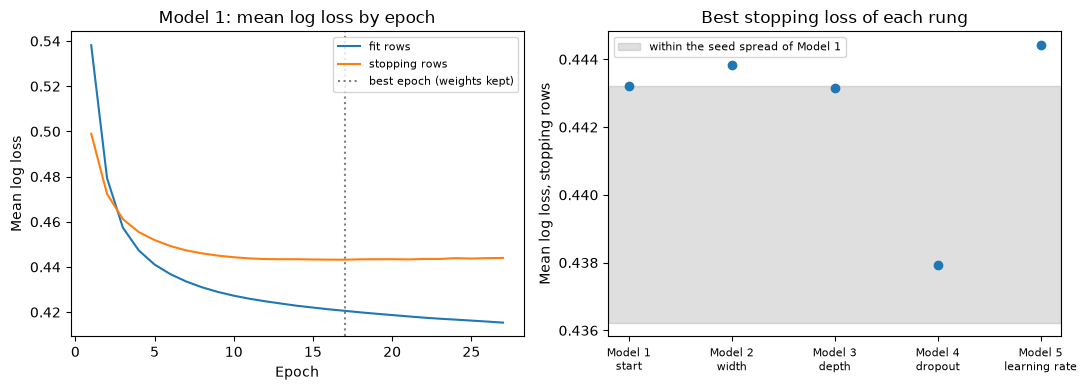

In [22]:
import matplotlib.pyplot as plt

curves = netkit.history_table(histories["Model 1"])
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(curves.index, curves["loss"], label="fit rows")
left.plot(curves.index, curves["val_loss"], label="stopping rows")
left.axvline(netkit.best_epoch(histories["Model 1"]), color="grey", linestyle=":", label="best epoch (weights kept)")
left.set_title("Model 1: mean log loss by epoch")
left.set_xlabel("Epoch")
left.set_ylabel("Mean log loss")
left.legend(fontsize=8)

# a change had to reach below the band: Model 1's stopping loss minus the seed spread
positions = np.arange(len(ladder))
right.axhspan(ladder.loc["Model 1", "stopping_loss"] - margin, ladder.loc["Model 1", "stopping_loss"], color="grey", alpha=0.25,
              label="within the seed spread of Model 1")
right.scatter(positions, ladder["stopping_loss"], zorder=3)
right.set_xticks(positions)
right.set_xticklabels([f"{m}\n{c}" for m, c in zip(ladder.index, ladder["change"])], fontsize=8)
right.set_title("Best stopping loss of each rung")
right.set_ylabel("Mean log loss, stopping rows")
right.legend(fontsize=8)
plt.tight_layout()
plt.show()

* Left: the fit loss keeps falling to the last epoch (0.4154 at epoch 27), while the stopping loss is lowest at epoch 17 and creeps up after it (0.4440 at epoch 27). Early stopping kept epoch 17's weights. Day 4's reading of a curve: from there on the network fits the fit rows better and the stopping rows worse.
* Right: the shaded band runs from Model 1's stopping loss down by the seed spread. Dropout lands inside the band; nothing reaches below it.

## 5.8 Thresholds From Out-of-Fold Outputs

Three models go to the validation rows: the chosen network, Course 4's logistic regression, and Course 5's LightGBM. Each needs its threshold for recall 0.70, chosen the same way on the training rows.

Q. Choose all three thresholds from out-of-fold outputs, and fit the two scikit-learn models on the training rows.

In [23]:
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# the chosen network is section 5.2's network with section 5.5's scaler, so its out-of-fold outputs are section 5.2's
assert settings == start and chosen_scaler == "StandardScaler"
oof_network = oof_standard
threshold_network = mlkit.threshold_for_recall(y_train, oof_network, 0.70)

# Course 5's LightGBM and Course 4's logistic regression: out-of-fold probabilities by the same five folds, then a fit
light = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1)
threshold_light, oof_light = ensemblekit.oof_threshold(light, X_train, y_train)
light.fit(X_train, y_train)
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
threshold_logistic, oof_logistic = ensemblekit.oof_threshold(logistic, X_train, y_train)
logistic.fit(X_train, y_train)

oof = {"chosen_network": oof_network, "course5_lightgbm": oof_light, "course4_logistic_regression": oof_logistic}
thresholds = {"chosen_network": threshold_network, "course5_lightgbm": threshold_light,
              "course4_logistic_regression": threshold_logistic}
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "oof_roc_auc": {name: roc_auc_score(y_train, output) for name, output in oof.items()},
    "oof_average_precision": {name: average_precision_score(y_train, output) for name, output in oof.items()},
})
print(threshold_table.round(4).to_string())

                             threshold  oof_roc_auc  oof_average_precision
chosen_network                  0.1758       0.7754                 0.5343
course5_lightgbm                0.1778       0.7743                 0.5483
course4_logistic_regression     0.2047       0.7273                 0.5084


* Inside the training rows, the network has the highest pooled out-of-fold ROC AUC (0.7754 against LightGBM's 0.7743), and LightGBM the highest average precision (0.5483 against 0.5343). The two measures do not agree on the order at the top, a first sign of how close the two are. The logistic regression is behind on both (0.7273 and 0.5084).
* The network's out-of-fold outputs come from networks fitted on four fifths of each fold's four fifths, with early stopping; the two scikit-learn models' come from `cross_val_predict` on the same five folds. Each threshold is the highest whose out-of-fold recall reaches 0.70.

## 5.9 Comparison on Validation Rows, With Intervals

Every choice is made: the scaler, the settings, the thresholds. Now the validation rows report, once, and each ROC AUC gets its bootstrap interval.

Q. Score the three models on the validation rows at their out-of-fold thresholds, with a 95 percent interval on each ROC AUC.

In [24]:
# each model's output on the validation rows: the network's from model.predict (scoring mode), the others' probabilities
output_network = network.predict(A_valid, verbose=0).ravel()
outputs = {"chosen_network": output_network, "course5_lightgbm": light.predict_proba(X_valid)[:, 1],
           "course4_logistic_regression": logistic.predict_proba(X_valid)[:, 1]}

rows = {}
for name, output in outputs.items():
    flags = (output >= thresholds[name]).astype(int)
    rows[name] = {"roc_auc": roc_auc_score(y_valid, output), "average_precision": average_precision_score(y_valid, output),
                  "threshold": thresholds[name], **mlkit.classification_metrics(y_valid, flags)}
valid_table = pd.DataFrame.from_dict(rows, orient="index")

# 1,000 resamples of the validation rows, seeded; nothing is refitted
interval_table = pd.DataFrame({name: ensemblekit.bootstrap_interval(y_valid, output, roc_auc_score)
                               for name, output in outputs.items()}, index=["lower", "upper"]).T
interval_table.insert(0, "roc_auc", valid_table["roc_auc"])
print(valid_table.round(4).to_string())
print()
print(interval_table.round(4).to_string())
print(f"all-zero baseline accuracy on the validation rows: {1 - y_valid.mean():.4f}")

                             roc_auc  average_precision  threshold  accuracy  precision  recall      f1
chosen_network                0.7696             0.5316     0.1758    0.6993     0.3987  0.7076  0.5100
course5_lightgbm              0.7725             0.5434     0.1778    0.7060     0.4043  0.6956  0.5114
course4_logistic_regression   0.7190             0.4946     0.2047    0.6230     0.3319  0.6956  0.4494

                             roc_auc   lower   upper
chosen_network                0.7696  0.7542  0.7847
course5_lightgbm              0.7725  0.7572  0.7871
course4_logistic_regression   0.7190  0.7010  0.7352
all-zero baseline accuracy on the validation rows: 0.7788


* Course 5's LightGBM ranks the validation accounts highest, 0.7725 (0.7572 to 0.7871); the network is next, 0.7696 (0.7542 to 0.7847); Course 4's logistic regression is well behind, 0.7190 (0.7010 to 0.7352). The order on average precision is the same: 0.5434, 0.5316, 0.4946.
* Inside the training rows the network had the higher pooled out-of-fold ROC AUC; on the validation rows LightGBM has. With gaps this small, which of the two comes first depends on which rows are scored.
* At the out-of-fold thresholds the network's validation recall is 0.7076, LightGBM's 0.6956 and the logistic regression's 0.6956: near 0.70, not on it, because a threshold set on one set of rows is not a guarantee on another. Nothing is moved to make them 0.70; moving them now would be choosing on the validation rows. Accuracy sits beside the all-zero baseline (0.7788) and chooses nothing.
* The network's average output on the validation rows, 0.2201, is close to the validation default rate, 0.2212: a network fitted without class weights gives the model probability of default in this file, and its average lands near the rate it was fitted on.

Q. The three were scored on the same rows, so their ROC AUCs rise and fall together. Put a paired interval on the network's difference from each of the other two, on the same 1,000 resamples.

In [25]:
# bootstrap_interval's own steps, written out, for all three models on each resample (Course 5 day 10's loop)
y_array = y_valid.to_numpy()
rng = np.random.default_rng(SEED)
resampled = {name: [] for name in outputs}
while len(resampled["chosen_network"]) < 1000:
    rows = rng.integers(0, len(y_array), len(y_array))
    # the function's rule: a resample with one class is drawn again
    if len(np.unique(y_array[rows])) < 2:
        continue
    for name, output in outputs.items():
        resampled[name].append(roc_auc_score(y_array[rows], output[rows]))
resampled = pd.DataFrame(resampled)
others = ["course5_lightgbm", "course4_logistic_regression"]
for name in others:
    resampled[f"network_minus_{name}"] = resampled["chosen_network"] - resampled[name]

# the same seed and the same rule, so the same resamples: bootstrap_interval's interval comes back
same = np.allclose(np.percentile(resampled["chosen_network"], [2.5, 97.5]), interval_table.loc["chosen_network", ["lower", "upper"]],
                   rtol=0, atol=1e-12)
print(f"the network's interval from the hand loop equals bootstrap_interval's within 1e-12: {same}")
paired = pd.DataFrame({name: np.percentile(resampled[f"network_minus_{name}"], [2.5, 97.5]) for name in others},
                      index=["lower", "upper"]).T
paired.insert(0, "difference", [valid_table.loc["chosen_network", "roc_auc"] - valid_table.loc[name, "roc_auc"] for name in others])
paired["network_higher_share"] = [(resampled[f"network_minus_{name}"] > 0).mean() for name in others]
print("validation ROC AUC of the network minus each model, 95 percent paired intervals:")
print(paired.round(4).to_string())

the network's interval from the hand loop equals bootstrap_interval's within 1e-12: True
validation ROC AUC of the network minus each model, 95 percent paired intervals:
                             difference   lower   upper  network_higher_share
course5_lightgbm                -0.0029 -0.0109  0.0048                 0.237
course4_logistic_regression      0.0506  0.0378  0.0635                 1.000


* **Against LightGBM**, the network's difference is -0.0029, with a paired interval from -0.0109 to 0.0048: it holds zero. The network ranks higher on 23.7 percent of the resamples and lower on the rest. On these rows the two cannot be told apart by ROC AUC.
* **Against the logistic regression**, the difference is +0.0506, with a paired interval from 0.0378 to 0.0635, clear of zero, and the network is higher on every resample. The network's lead over the linear model is larger than the noise from which rows were scored.
* The paired interval against LightGBM is 0.0157 wide, against 0.0304 for the network's own interval: the two models rise and fall together across resamples, so their difference moves far less than either score. That is why the paired difference, not two separate intervals, is the test.
* Every interval here describes the noise from which accounts were scored. None covers refitting with another seed, which section 5.6 showed moves a network's stopping loss by 0.0070.

Q. Draw each model's validation ROC AUC with its interval.

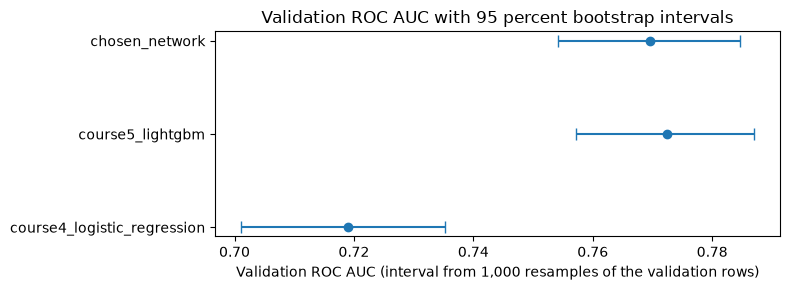

In [26]:
fig, ax = plt.subplots(figsize=(8, 3))
names = list(interval_table.index)
positions = np.arange(len(names))
# a bar from the lower to the upper end of each interval, and the validation ROC AUC as a dot
ax.errorbar(interval_table["roc_auc"], positions,
            xerr=[interval_table["roc_auc"] - interval_table["lower"], interval_table["upper"] - interval_table["roc_auc"]],
            fmt="o", capsize=4)
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_title("Validation ROC AUC with 95 percent bootstrap intervals")
ax.set_xlabel("Validation ROC AUC (interval from 1,000 resamples of the validation rows)")
plt.tight_layout()
plt.show()

* The network's bar and LightGBM's sit almost on top of each other; the logistic regression's is clear of both.

## 5.10 The Results Workbook

Three sheets: `comparison` (the validation table), `intervals` (each ROC AUC with its interval), and `thresholds` (each threshold and the pooled out-of-fold scores).

Q. Write `card_network_results.xlsx` with `pd.ExcelWriter`, then read it back and check that nothing changed on the way.

In [27]:
# one table per sheet: the validation comparison, the intervals, and the thresholds chosen on the training rows
comparison = valid_table.assign(rows="validation").rename_axis("model").reset_index()
comparison = comparison[["model", "rows", "roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall", "f1"]]
interval_sheet = interval_table.rename_axis("model").reset_index()
threshold_sheet = threshold_table.rename_axis("model").reset_index()

# ExcelWriter with openpyxl, one sheet per table; the workbook goes in the work folder, never in the course folder
with pd.ExcelWriter("card_network_results.xlsx", engine="openpyxl") as writer:
    comparison.to_excel(writer, sheet_name="comparison", index=False)
    interval_sheet.to_excel(writer, sheet_name="intervals", index=False)
    threshold_sheet.to_excel(writer, sheet_name="thresholds", index=False)

# sheet_name=None reads every sheet, in the workbook's order
back = pd.read_excel("card_network_results.xlsx", sheet_name=None)
print(f"sheets: {list(back)}; rows {[len(frame) for frame in back.values()]}")
for name, frame in [("comparison", comparison), ("intervals", interval_sheet), ("thresholds", threshold_sheet)]:
    pd.testing.assert_frame_equal(back[name], frame, check_exact=False, rtol=1e-12)
print("all three sheets equal after the round trip")

sheets: ['comparison', 'intervals', 'thresholds']; rows [3, 3, 3]
all three sheets equal after the round trip


* Three sheets, in the order written, and every number back within 1e-12. Excel opened this workbook too (Excel Side by Side).

## 5.11 What the Model Shows, and Where It Fails

Q. On which validation accounts is the network wrong? Split its misses and its false flags by the September status, and count the defaults all three models miss.

In [28]:
# the network's flags at its out-of-fold threshold, on the validation rows
flags = (output_network >= threshold_network).astype(int)
pay_0 = X_valid["PAY_0"]
missed = (y_valid == 1) & (flags == 0)
false_flags = (y_valid == 0) & (flags == 1)
low_status = (y_valid == 1) & (pay_0 <= 0)
print(f"flagged: {flags.sum():,} of {len(flags):,}")
print(f"defaults not flagged: {missed.sum():,}; of them with a September status of 0 or below: {(missed & (pay_0 <= 0)).sum():,}")
print(f"defaults with a September status of 0 or below: {low_status.sum():,}, of them flagged: {(low_status & (flags == 1)).sum():,}")
print(f"defaults with a September delay of 1 month or more: {((y_valid == 1) & (pay_0 >= 1)).sum():,}, "
      f"of them flagged: {((y_valid == 1) & (pay_0 >= 1) & (flags == 1)).sum():,}")
print(f"non-defaults flagged: {false_flags.sum():,}; of them with a September delay of 1 month or more: {(false_flags & (pay_0 >= 1)).sum():,}")

# the defaults that none of the three models flags at its own threshold
all_flags = {name: (output >= thresholds[name]).astype(int) for name, output in outputs.items()}
missed_by_all = (y_valid == 1) & (all_flags["chosen_network"] == 0) & (all_flags["course5_lightgbm"] == 0) & (all_flags["course4_logistic_regression"] == 0)
print(f"defaults missed by all three models: {missed_by_all.sum():,}; of them with a September status of 0 or below: {(missed_by_all & (pay_0 <= 0)).sum():,}")
print(f"correlation of the network's and LightGBM's validation outputs: {np.corrcoef(output_network, outputs['course5_lightgbm'])[0, 1]:.4f}")

flagged: 2,355 of 6,000
defaults not flagged: 388; of them with a September status of 0 or below: 377
defaults with a September status of 0 or below: 660, of them flagged: 283
defaults with a September delay of 1 month or more: 667, of them flagged: 656
non-defaults flagged: 1,416; of them with a September delay of 1 month or more: 607
defaults missed by all three models: 200; of them with a September status of 0 or below: 199
correlation of the network's and LightGBM's validation outputs: 0.9198


* 377 of the network's 388 missed defaults had a September status of 0 or below. Of the 667 validation defaults with a delay of a month or more it flagged 656; of the 660 with no recorded delay, 283. Like Course 5's boosters, the network finds defaults mostly through a recent delay.
* 607 of its 1,416 false flags had a September delay of a month or more: accounts that were late and did not default the next month.
* 200 defaults are missed by all three models, 199 of them with no recorded September delay, and the network's outputs correlate 0.9198 with LightGBM's. Two very different kinds of model, fitted on the same 19 columns, rank the accounts in much the same order and miss many of the same defaults.

Q. Write the description, and check its words.

In [29]:
row = valid_table.loc["chosen_network"]
low, high = interval_table.loc["chosen_network", ["lower", "upper"]]
light_low, light_high = paired.loc["course5_lightgbm", ["lower", "upper"]]
description = (
    f"On the {len(X_valid):,} validation rows of the UCI card file (accounts in Taiwan in 2005), a dense network with "
    f"two hidden layers of 64 and 32 units, chosen on stopping rows carved from the {len(X_train):,} training rows, had "
    f"a ROC AUC of {row['roc_auc']:.4f} (bootstrap interval {low:.4f} to {high:.4f}) and an average precision of "
    f"{row['average_precision']:.4f}. Course 5's LightGBM had {valid_table.loc['course5_lightgbm', 'roc_auc']:.4f} and "
    f"Course 4's logistic regression {valid_table.loc['course4_logistic_regression', 'roc_auc']:.4f}. On 1,000 paired "
    f"resamples of these rows the network's difference from LightGBM ran from {light_low:.4f} to {light_high:.4f}, an "
    f"interval that holds zero, and its lead over the logistic regression stayed above zero (lower end "
    f"{paired.loc['course4_logistic_regression', 'lower']:.4f}). Flagged at threshold {row['threshold']:.4f}, set on "
    f"out-of-fold outputs for a recall of 0.70, it flagged {flags.sum():,} accounts and caught {row['recall']:.2%} of "
    f"the validation defaults; {row['precision']:.2%} of the flagged accounts defaulted. Of the {missed.sum():,} "
    f"defaults it did not flag, {(missed & (pay_0 <= 0)).sum():,} had a September status of 0 or below. The file "
    f"covers one place and one period, and the documentation does not say how the accounts were chosen."
)
# stops on a forecast, advice, lending, or cause word; a reminder, not a proof
ensemblekit.assert_described(description)
print(description)

On the 6,000 validation rows of the UCI card file (accounts in Taiwan in 2005), a dense network with two hidden layers of 64 and 32 units, chosen on stopping rows carved from the 18,000 training rows, had a ROC AUC of 0.7696 (bootstrap interval 0.7542 to 0.7847) and an average precision of 0.5316. Course 5's LightGBM had 0.7725 and Course 4's logistic regression 0.7190. On 1,000 paired resamples of these rows the network's difference from LightGBM ran from -0.0109 to 0.0048, an interval that holds zero, and its lead over the logistic regression stayed above zero (lower end 0.0378). Flagged at threshold 0.1758, set on out-of-fold outputs for a recall of 0.70, it flagged 2,355 accounts and caught 70.76% of the validation defaults; 39.87% of the flagged accounts defaulted. Of the 388 defaults it did not flag, 377 had a September status of 0 or below. The file covers one place and one period, and the documentation does not say how the accounts were chosen.


The description passes the check, and it was read sentence by sentence as well, because the check is a reminder, not a proof. Every number in it is a model's output on rows that chose nothing.

**What the model shows.** On this file, a small dense network with two hidden layers, fitted with early stopping on carved rows and scaled on its fit rows only, ranks the validation accounts at 0.7696: above Course 4's logistic regression by more than the noise from which accounts were scored, and level with Course 5's LightGBM within that noise. LightGBM's ROC AUC and average precision are both a little higher on these rows, and the paired interval cannot say the gap is more than resampling.

**Where it fails.**

* **On rows.** Defaults with no recorded September delay are mostly missed, and late accounts that did not default are often flagged. At its threshold, 60.1 percent of the flagged validation accounts did not default. The other two models miss most of the same defaults.
* **On the choice.** No setting on the ladder beat the seed spread, so the chosen network is the course's default. A ladder with more seeds per rung, or other rungs, could have chosen differently; dropout's gain came nearest to the bar.
* **On the threshold.** A threshold set for recall 0.70 on out-of-fold outputs reached 0.7076 on the validation rows. A threshold set on one set of rows is not a guarantee on another.
* **On the seed.** The intervals cover which rows were scored, not which seed was used. Section 5.6 measured the seed's effect on the stopping rows; the validation numbers above are seed 42's.
* **On the codes.** Every model reads the undefined codes -2 and 0 as numbers below 1; the documentation cannot settle what they mean.

**What the data cannot support.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender. The page does not say how the accounts were chosen or exactly when the outcome was measured. The models' outputs describe this file; they are not a risk measure for any person, and no threshold here is a lending rule.

**What was not tested.** The test rows, by the course's rule; more seeds per rung, longer ladders, other widths, batch sizes, and optimizers (week 2 takes those one at a time); class weights (day 10); the networks' calibration beyond their mean; whether the relationships hold in a later period; and any cost attached to a missed default or a false flag, which this course does not assign.

## Excel Side by Side

Excel has no network training, no cross-validation, and no seeded bootstrap, so the fitting and the resampling stay in Python. Excel can do everything that comes after: count flags at a threshold, turn counts into precision and recall, take percentiles of resampled scores, and open the workbook. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-06) on values pasted in from this notebook: on a sheet named `flags`, the 6,000 validation outcomes in A2:A6001, the network's outputs in B2:B6001, and its threshold, 0.1758, in F1; on a sheet named `resamples`, the 1,000 resampled ROC AUCs of section 5.9, one column per model and one per paired difference.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Flag at the threshold | `(output_network >= threshold_network)` | `=IF(B2>=$F$1,1,0)` in C2, filled down | |
| Defaults flagged (TP) | `mlkit.confusion_counts(...)["tp"]` | `=COUNTIFS(A2:A6001,1,C2:C6001,1)` | 939 |
| Non-defaults flagged (FP) | `["fp"]` | `=COUNTIFS(A2:A6001,0,C2:C6001,1)` | 1,416 |
| Defaults missed (FN) | `["fn"]` | `=COUNTIFS(A2:A6001,1,C2:C6001,0)` | 388 |
| Non-defaults not flagged (TN) | `["tn"]` | `=COUNTIFS(A2:A6001,0,C2:C6001,0)` | 3,257 |
| Precision | `valid_table.loc["chosen_network", "precision"]` | `=F3/(F3+F4)` | 0.3987 |
| Recall | `valid_table.loc["chosen_network", "recall"]` | `=F3/(F3+F5)` | 0.7076 |
| The network's interval | `bootstrap_interval(...)` | `=PERCENTILE.INC(A2:A1001,0.025)` and `=PERCENTILE.INC(A2:A1001,0.975)` | 0.7542 to 0.7847 |
| Paired interval against LightGBM | `paired.loc["course5_lightgbm"]` | `=PERCENTILE.INC(D2:D1001,0.025)` and `=PERCENTILE.INC(D2:D1001,0.975)` | -0.0109 to 0.0048 |
| Paired interval against the logistic regression | `paired.loc["course4_logistic_regression"]` | `=PERCENTILE.INC(E2:E1001,0.025)` and `=PERCENTILE.INC(E2:E1001,0.975)` | 0.0378 to 0.0635 |
| Share of resamples where the network is higher than LightGBM | `(resampled[...] > 0).mean()` | `=COUNTIF(D2:D1001,">0")/COUNT(D2:D1001)` | 0.2370 |

**Flags and counts.** `IF(B2>=$F$1,1,0)` in C2, filled down, is the flag column: 1 where the network's output is at or above the threshold. `COUNTIFS` with two conditions counts the rows that meet both, so `COUNTIFS(A2:A6001,1,C2:C6001,1)` is the defaults the network flagged, and the other three pairs of 0 and 1 give the rest of the confusion matrix. The four counts add up to 6,000. Precision divides the defaults flagged by everything flagged; recall divides them by every default.

**Percentiles.** `PERCENTILE.INC` with 0.025 and 0.975 on the network's 1,000 resampled ROC AUCs returned `bootstrap_interval`'s two ends, which numpy computes with its default linear method. On the paired-difference columns it gives the paired intervals of section 5.9, and `COUNTIF(...,">0")/COUNT(...)` the share of resamples on which the network is higher. The resampling itself has to come from Python: the rows of each resample are drawn by a seeded generator, so the same 1,000 resamples come back on every run.

**The workbook.** `Workbooks.Open` on `card_network_results.xlsx` showed the sheets `comparison`, `intervals`, `thresholds`, in that order, with the model names in column A and 3 models on each. Each of the 39 numbers Excel holds equals Python's within 1e-12.

Q. Do Excel's numbers equal Python's?

In [30]:
# what Excel returned (from the course's Excel check), beside the same numbers from Python
counts = mlkit.confusion_counts(y_valid, flags)
excel = {"defaults flagged (TP)": 939, "non-defaults flagged (FP)": 1416,
         "defaults missed (FN)": 388, "non-defaults not flagged (TN)": 3257,
         "precision": 0.39872611464968155, "recall": 0.707611152976639,
         "network interval, lower": 0.7542434890576483, "network interval, upper": 0.7846629449609155,
         "network minus LightGBM, lower": -0.010851094567824071, "network minus LightGBM, upper": 0.004822711712047507,
         "network minus logistic, lower": 0.03784917010732509, "network minus logistic, upper": 0.06351284876281851,
         "share where the network is higher than LightGBM": 0.237}
python = {"defaults flagged (TP)": counts["tp"], "non-defaults flagged (FP)": counts["fp"],
          "defaults missed (FN)": counts["fn"], "non-defaults not flagged (TN)": counts["tn"],
          "precision": valid_table.loc["chosen_network", "precision"], "recall": valid_table.loc["chosen_network", "recall"],
          "network interval, lower": interval_table.loc["chosen_network", "lower"],
          "network interval, upper": interval_table.loc["chosen_network", "upper"],
          "network minus LightGBM, lower": paired.loc["course5_lightgbm", "lower"],
          "network minus LightGBM, upper": paired.loc["course5_lightgbm", "upper"],
          "network minus logistic, lower": paired.loc["course4_logistic_regression", "lower"],
          "network minus logistic, upper": paired.loc["course4_logistic_regression", "upper"],
          "share where the network is higher than LightGBM": paired.loc["course5_lightgbm", "network_higher_share"]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python}).astype(float)
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.round(4).to_string())

                                                     Excel     Python  within 1e-12
defaults flagged (TP)                             939.0000   939.0000          True
non-defaults flagged (FP)                        1416.0000  1416.0000          True
defaults missed (FN)                              388.0000   388.0000          True
non-defaults not flagged (TN)                    3257.0000  3257.0000          True
precision                                           0.3987     0.3987          True
recall                                              0.7076     0.7076          True
network interval, lower                             0.7542     0.7542          True
network interval, upper                             0.7847     0.7847          True
network minus LightGBM, lower                      -0.0109    -0.0109          True
network minus LightGBM, upper                       0.0048     0.0048          True
network minus logistic, lower                       0.0378     0.0378       

* Every number matches within 1e-12, and the four counts exactly. The flag column compares two doubles directly, which is why the threshold sits in its own cell and the flags in their own column rather than in a text condition such as `">="&F1`.

## Save the Day with Git

Week 1 ends today, so the day's Git step names the commit that ends it. The work folder is new, so first the day's code, then the experiment log in two commits: the out-of-fold numbers on the training rows, then the validation numbers. The week's name goes on the last commit.

Q. Make the work folder a repository.

In [31]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [32]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course6_05_6oxi9z8v and nowhere else


Q. Tell Git which files never to track: Python's bytecode cache, pytest's cache, Excel workbooks, and saved Keras models.

In [33]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
*.keras

Writing .gitignore


Q. Commit `.gitignore`, the two earlier modules, and the two netkit files as they stand after today's functions.

In [34]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py netkit.py test_netkit.py
!git -C "{work}" commit -q -m "Add dense_classifier and cv_network: a seeded network and out-of-fold outputs, 24 tests"
!git -C "{work}" log --oneline

baa7317 Add dense_classifier and cv_network: a seeded network and out-of-fold outputs, 24 tests


Q. Start today's experiment log with the out-of-fold numbers on the training rows (`rows` is `cv`), and commit it.

In [35]:
# rows = "cv": pooled out-of-fold outputs on the training rows, flagged at each model's own threshold
cv_rows = []
for name in oof:
    flag_oof = (oof[name] >= thresholds[name]).astype(int)
    cv_rows.append({"model": name, "rows": "cv", "roc_auc": threshold_table.loc[name, "oof_roc_auc"],
                    "average_precision": threshold_table.loc[name, "oof_average_precision"],
                    "threshold": thresholds[name], **mlkit.classification_metrics(y_train, flag_oof)})
log_cv = pd.DataFrame(cv_rows)
log_cv.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
chosen_network,cv,0.7754,0.5343,0.1758,0.7056,0.4045,0.7002,0.5127
course5_lightgbm,cv,0.7743,0.5483,0.1778,0.7061,0.4050,0.7002,0.5132
course4_logistic_regression,cv,0.7273,0.5084,0.2047,0.6239,0.3333,0.7002,0.4516



In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: three card models, pooled out-of-fold outputs on the training rows"
!git -C "{work}" log --oneline -1

5d254ed Experiment log: three card models, pooled out-of-fold outputs on the training rows


Q. Add the validation rows (`rows` is `validation`), commit, and put the name `week1` on that commit.

In [37]:
# the validation comparison of section 5.9, in the log's nine columns, below the cv rows
log_valid = valid_table.assign(rows="validation").rename_axis("model").reset_index()[log_cv.columns]
results = pd.concat([log_cv, log_valid], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
chosen_network,cv,0.7754,0.5343,0.1758,0.7056,0.4045,0.7002,0.5127
course5_lightgbm,cv,0.7743,0.5483,0.1778,0.7061,0.4050,0.7002,0.5132
course4_logistic_regression,cv,0.7273,0.5084,0.2047,0.6239,0.3333,0.7002,0.4516
chosen_network,validation,0.7696,0.5316,0.1758,0.6993,0.3987,0.7076,0.5100
course5_lightgbm,validation,0.7725,0.5434,0.1778,0.7060,0.4043,0.6956,0.5114
course4_logistic_regression,validation,0.7190,0.4946,0.2047,0.6230,0.3319,0.6956,0.4494



In [38]:
# commit, then put the name week1 on that commit; --decorate shows the name
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the three card models on the validation rows, at out-of-fold thresholds"
!git -C "{work}" tag week1
!git -C "{work}" log --oneline --decorate

8ca1799 (HEAD -> main, tag: week1) Experiment log: the three card models on the validation rows, at out-of-fold thresholds
5d254ed Experiment log: three card models, pooled out-of-fold outputs on the training rows
baa7317 Add dense_classifier and cv_network: a seeded network and out-of-fold outputs, 24 tests


Q. What did the last commit of week 1 change in the log? Compare the commit before `week1` with `week1`.

In [39]:
# week1~1 is the commit before week1; -- results.csv limits the diff to one file
!git -C "{work}" diff week1~1 week1 -- results.csv

diff --git a/results.csv b/results.csv
index 417d061..b9cd8a7 100644
--- a/results.csv
+++ b/results.csv
@@ -2,3 +2,6 @@ model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 chosen_network,cv,0.7754,0.5343,0.1758,0.7056,0.4045,0.7002,0.5127
 course5_lightgbm,cv,0.7743,0.5483,0.1778,0.7061,0.4050,0.7002,0.5132
 course4_logistic_regression,cv,0.7273,0.5084,0.2047,0.6239,0.3333,0.7002,0.4516
+chosen_network,validation,0.7696,0.5316,0.1758,0.6993,0.3987,0.7076,0.5100
+course5_lightgbm,validation,0.7725,0.5434,0.1778,0.7060,0.4043,0.6956,0.5114
+course4_logistic_regression,validation,0.7190,0.4946,0.2047,0.6230,0.3319,0.6956,0.4494


* Three `+` lines: the validation rows, added below the three `cv` rows, which did not change. On the `cv` rows every recall is at least 0.70 by construction, since the thresholds were set there; on the `validation` rows the recalls are what those thresholds gave on rows that set nothing.
* `week1~1` means "one commit before `week1`". A tag works anywhere a commit does, so from now on `git diff week1 HEAD -- netkit.py` shows everything week 2 adds to the module.

## Bring It Home

Add today's two functions and their tests to your own `my_bondmath` folder, run the tests, commit, and name the end of week 1. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code netkit.py
code test_netkit.py
```

**Step 2.** At the end of `netkit.py`, paste the code of the two `%%writefile -a netkit.py` cells (sections 5.1 and 5.2), without their first lines, one after the other. At the end of `test_netkit.py`, paste the `%%writefile -a test_netkit.py` cell of section 5.2 the same way. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_netkit.py
```

The last line says `24 passed`.

**Step 4.** Read the change, commit, and name the week.

```powershell
git diff --stat
git add netkit.py test_netkit.py
git commit -m "Add dense_classifier and cv_network: a seeded network and out-of-fold outputs, 24 tests"
git tag week1
git log --oneline --decorate -3
```

Your folder keeps code only. The results workbook and `results.csv` stay in the work folder.

**In Colab**, download `netkit.py` and `test_netkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Build the course's network with `dense_classifier`, and say why building inside a function that seeds it matters.
* Cross-validate a network with `cv_network`, with stopping rows and a scaler fitted inside each fold, and choose a threshold from its out-of-fold outputs.
* Say why the course scores with scikit-learn rather than `keras.metrics.AUC`.
* Choose a transformer by out-of-fold average precision, measure how much the seed alone moves a network, and keep a change of setting only when it beats that.
* Put a network beside logistic regression and LightGBM on the same validation rows, with separate and paired bootstrap intervals, and say what the numbers support.
* Write what a network shows and where it fails, and name the end of a week with `git tag`.

Next, day 6 opens week 2 on the synthetic benchmark bonds: a network for a number rather than a flag, its loss functions, and the learning rate.

## Exercises

The exercises use the case study's rows, models, and outputs: fitted on Course 4's 18,000 training rows, thresholds chosen inside them, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It checks that the case study's variables are there (run the notebook from the top if one is missing), collects the validation outputs under short names, and defines `check`.

In [40]:
# the exercises use the case study's variables: stop if the notebook was not run from the top
needed = ["X_train", "X_fit", "transformer", "settings", "fit_network", "network", "output_network", "oof_network",
          "oof_light", "oof_logistic", "light", "logistic", "seed_table"]
missing = [name for name in needed if name not in globals()]
assert not missing, f"run the notebook from the top first: {missing} not defined"
proba_light = light.predict_proba(X_valid)[:, 1]
proba_logistic = logistic.predict_proba(X_valid)[:, 1]
seed_aucs = seed_table["stopping_roc_auc"].tolist()


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Repeat the comparison for a desk that asks for a recall of 0.60 instead of 0.70. For each of the three models, choose the threshold with `mlkit.threshold_for_recall(y_train, ..., 0.60)` on its out-of-fold outputs (`oof_network`, `oof_light`, `oof_logistic`), flag the validation rows at it, and store a dictionary of model name (`chosen_network`, `course5_lightgbm`, `course4_logistic_regression`) to validation precision, rounded to 4 decimals, in **ex1_precision**.

In [41]:
ex1_precision = ...

In [42]:
check("Exercise 1 precision at recall 0.60", ex1_precision, {'chosen_network': 0.4863, 'course5_lightgbm': 0.4867, 'course4_logistic_regression': 0.4403})

Exercise 1 precision at recall 0.60: not attempted yet


### Exercise 2

Q. Fit the chosen network without `PAY_0`: take the other 18 columns of the fit, stopping, and validation rows, scale them with `netkit.fit_arrays(transformer, ...)`, fit with `fit_network(..., **settings)`, and store the validation ROC AUC in **ex2_auc**. How much of the network's ranking rests on the September status?

In [43]:
ex2_auc = ...

In [44]:
check("Exercise 2 validation ROC AUC without PAY_0", ex2_auc, 0.7417443696419537)

Exercise 2 validation ROC AUC without PAY_0: not attempted yet


### Exercise 3

Q. Add a function to your module. `seed_spread(scores)` returns a dictionary with the range (largest minus smallest) and the standard deviation (`ddof=0`) of one score across seeds, and raises `ValueError` on fewer than two scores. Write the docstring first. Then add `test_seed_spread_hand`, which checks the range and the standard deviation of `[0.70, 0.72, 0.74]` by hand and the error on a single score. Run pytest, reload the module, and store the range and standard deviation of `seed_aucs` (the five stopping-row ROC AUCs of section 5.6) in **ex3_range** and **ex3_sd**.

Write the function in the cell that starts with `%%writefile -a netkit.py` and the test in the one that starts with `%%writefile -a test_netkit.py`, and run each of those cells once.

In [45]:
%%writefile -a netkit.py


# Exercise 3: write seed_spread(scores) below this line

Appending to netkit.py


In [46]:
%%writefile -a test_netkit.py


# Exercise 3: write test_seed_spread_hand() below this line

Appending to test_netkit.py


In [47]:
# run pytest, reload the module, then use your function
ex3_range = ...
ex3_sd = ...

In [48]:
check("Exercise 3 the range", ex3_range, 0.0048721227392312105)
check("Exercise 3 the standard deviation", ex3_sd, 0.0016880425081160924)

Exercise 3 the range: not attempted yet
Exercise 3 the standard deviation: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that gives the network's threshold for recall 0.70 and the recall it reaches on the validation rows, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The network's threshold for recall 0.70, and the recall it gives on the validation rows.

    Inputs: y_train and oof_output, the training rows' outcomes and their out-of-fold outputs from cv_network;
    y_valid and valid_output, the validation rows' outcomes and the chosen network's outputs on them;
    target_recall, the share of defaults the threshold must catch.
    Output: (threshold, validation recall). The threshold is chosen on the training rows' out-of-fold outputs
    only; the validation rows report the recall it gives and choose nothing.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a threshold and a recall that look right, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def threshold_and_recall(y_train, oof_output, y_valid, valid_output, target_recall=0.70):
    """The network's threshold for recall 0.70, and the recall it gives on the validation rows.

    Inputs: y_train and oof_output, the training rows' outcomes and their out-of-fold outputs from cv_network;
    y_valid and valid_output, the validation rows' outcomes and the chosen network's outputs on them;
    target_recall, the share of defaults the threshold must catch.
    Output: (threshold, validation recall). The threshold is chosen on the training rows' out-of-fold outputs
    only; the validation rows report the recall it gives and choose nothing.
    """
    # the highest threshold that still catches the target share of defaults
    threshold = mlkit.threshold_for_recall(y_valid, valid_output, target_recall)
    flags = (np.asarray(valid_output) >= threshold).astype(int)
    return threshold, mlkit.classification_metrics(y_valid, flags)["recall"]

Q. Before you run the next cell: what validation recall will this function report? Section 5.9's threshold, chosen on the training rows, gave a recall near 0.70 but not on it.

In [50]:
ai_threshold, ai_recall = threshold_and_recall(y_train, oof_network, y_valid, output_network)
print(f"threshold_and_recall: threshold {ai_threshold:.4f}, validation recall {ai_recall:.4f}")

threshold_and_recall: threshold 0.1786, validation recall 0.7001


Q. Test the function against its docstring before you trust it: its threshold must be the one the out-of-fold outputs on the training rows give.

In [51]:
# the test, written from the docstring before the code is trusted
ai_threshold, ai_recall = threshold_and_recall(y_train, oof_network, y_valid, output_network)

# the threshold must come from the out-of-fold outputs on the training rows, as cv_network gave them
from_training = mlkit.threshold_for_recall(y_train, oof_network, 0.70)
assert abs(ai_threshold - from_training) < 1e-12, (f"threshold {ai_threshold:.4f}, but the out-of-fold outputs on the "
                                                   f"training rows give {from_training:.4f}")
print(f"threshold {ai_threshold:.4f} from the training rows; validation recall {ai_recall:.4f}")

AssertionError: threshold 0.1786, but the out-of-fold outputs on the training rows give 0.1758

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's validation recall, `threshold_and_recall(y_train, oof_network, y_valid, output_network)[1]`, in **ex4_recall**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_recall = ...

In [53]:
check("Exercise 4 the fixed function's validation recall", ex4_recall, 0.707611152976639)

Exercise 4 the fixed function's validation recall: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```